# 🧠 CNNs and Transfer Learning — Teaching Computers to See

> **What you'll learn:** why convolutions work for images, the output-size / parameter / receptive-field arithmetic interviewers love, pooling and BatchNorm, how architectures evolved from LeNet to ResNet, EfficientNet, ViT and ConvNeXt, data augmentation with `torchvision.transforms.v2`, training a CNN from scratch on real CIFAR-10, transfer learning done right with pretrained weights, evaluation beyond accuracy, Grad-CAM explanations, and exporting a model and measuring its real latency.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced |
| **Time** | ~6 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [OpenCV](01_OpenCV.ipynb) (images as arrays, convolution, filters) · [PyTorch](../04_Deep_Learning/02_PyTorch.ipynb) (tensors, autograd, `nn.Module`, training loops) |
| **Tested with** | Python 3.12 · torch 2.14 · torchvision 0.29 · scikit-learn 1.9 · pandas 3.0 · matplotlib 3.11 · Apple Silicon GPU (MPS) |
| **Interview relevance** | ⭐⭐⭐ High — conv output-size and parameter formulas, receptive field, why ResNets work, BatchNorm train vs eval, transfer-learning strategy, augmentation choices, Grad-CAM, export and latency |

## 🤔 What Is a CNN?

A **convolutional neural network (CNN)** is a neural network whose main building block is the **convolution** you met in the OpenCV notebook: a small kernel sliding over the image. The difference: in OpenCV *you* chose the kernel (Sobel, Gaussian); in a CNN the network **learns** thousands of kernels from labeled examples.

Think of a factory line of inspectors:

```
 image ─► [layer 1: edges, color blobs] ─► [layer 2: corners, textures] ─► [layer 3: eyes, wheels, petals] ─► [head: one score per class]
          small kernels, see ~3×3 px        see a bigger patch              see most of the object            → "church"
```

Early inspectors look at tiny patches and report simple patterns; later inspectors combine those reports and see bigger and bigger regions, until the last one can say *what* is in the picture.

**Transfer learning** means borrowing a network someone already trained on millions of images (e.g. ImageNet, 1.28 million photos in 1,000 classes) and adapting it to *your* task. Its early and middle layers already detect generally useful patterns, so you need far less data and compute than training from scratch.

## 🎯 Why It Matters

- **CNNs power most production vision.** Photo search, medical imaging triage, defect inspection, document understanding, autonomous-driving perception, and the backbones inside detectors like YOLO (next notebook).
- **Transfer learning is the default workflow.** Almost nobody trains an image model from random weights at work; you fine-tune a pretrained backbone. Knowing *how* (which layers, which learning rates, which preprocessing) separates good results from mysteriously bad ones.
- **The math is interview bread-and-butter.** "What is the output shape of this layer?", "How many parameters?", "What's the receptive field?", "Why do skip connections help?", "Why does my model behave differently in `eval()`?"
- **Vision Transformers didn't make CNNs obsolete.** ConvNeXt and EfficientNet-style CNNs remain strong, cheap to serve, and are the first thing to try on small datasets and edge devices.

## ✅ By the End You Can

- [ ] Compute a convolution's output size, parameter count, and receptive field by hand — and verify them in code
- [ ] Explain local connectivity, weight sharing, translation equivariance, pooling, BatchNorm, and ResNet skip connections
- [ ] Build a leak-free augmentation pipeline with `transforms.v2` and train a CNN from scratch on real CIFAR-10
- [ ] Transfer-learn correctly: use the weights' own preprocessing, choose between feature extraction and fine-tuning, freeze layers, and use a lower backbone learning rate
- [ ] Evaluate with confusion matrices, per-class and top-k accuracy, and explain predictions with Grad-CAM
- [ ] Export a model with `torch.export` and measure latency and throughput correctly on CPU and GPU

## 📋 Table of Contents

1. [Why Convolutions?](#1.-Why-Convolutions?-🟢)
2. [Conv Arithmetic: Output Size and Parameters](#2.-Conv-Arithmetic:-Output-Size-and-Parameters-🟡)
3. [Receptive Field](#3.-Receptive-Field-🟡)
4. [Pooling and BatchNorm](#4.-Pooling-and-BatchNorm-🟡)
5. [Architecture Evolution: LeNet to ConvNeXt](#5.-Architecture-Evolution:-LeNet-to-ConvNeXt-🟡)
6. [Data Augmentation With transforms.v2](#6.-Data-Augmentation-With-transforms.v2-🟢)
7. [Training a Small CNN From Scratch on CIFAR-10](#7.-Training-a-Small-CNN-From-Scratch-on-CIFAR-10-🟡)
8. [Evaluation: Confusion Matrix, Per-Class and Top-k Accuracy](#8.-Evaluation:-Confusion-Matrix,-Per-Class-and-Top-k-Accuracy-🟢)
9. [Pretrained Weights and Their Preprocessing](#9.-Pretrained-Weights-and-Their-Preprocessing-🟡)
10. [Transfer Learning Strategies](#10.-Transfer-Learning-Strategies-🔴)
11. [Grad-CAM: Where Is the Model Looking?](#11.-Grad-CAM:-Where-Is-the-Model-Looking?-🔴)
12. [Exporting and Measuring Inference Speed](#12.-Exporting-and-Measuring-Inference-Speed-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Scratch-vs-Frozen-vs-Fine-Tuned-on-Imagenette) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

- **Hardware.** The notebook picks Apple's GPU (**MPS**), then CUDA, then CPU. Everything was timed on an Apple Silicon laptop: the whole notebook takes about 5–6 minutes there. On a CPU-only machine the training cells are several times slower — lower the `*_EPOCHS` constants.
- **Downloads (~315 MB, once).** CIFAR-10 (170 MB) and Imagenette 160px (99 MB) are cached in `_outputs/data/`; ResNet-18 ImageNet weights (45 MB) go to PyTorch's standard cache (`~/.cache/torch/hub/checkpoints`).
- **Honest scope.** To stay within a laptop budget we train for few epochs. Numbers are real but not state-of-the-art; the *comparisons* are what matter.
- The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "torch>=2.5" "torchvision>=0.20" "scikit-learn>=1.5" "pandas>=2.2" matplotlib pillow

import copy
import gc
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from PIL import Image
from sklearn.datasets import load_sample_image
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, top_k_accuracy_score
from sklearn.model_selection import train_test_split
from torchvision import datasets, models, tv_tensors
from torchvision.transforms import v2

print(f"Python {sys.version.split()[0]} | torch {torch.__version__} | torchvision {torchvision.__version__} | "
      f"scikit-learn {sklearn.__version__} | pandas {pd.__version__}")

SEED = 42
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)
pd.set_option("display.precision", 3)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
    print("⚠️ No GPU found: training cells will be slow on CPU — consider lowering the *_EPOCHS constants.")
print("device:", DEVICE)

OUTPUT_DIR = Path("_outputs")
DATA_DIR = OUTPUT_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

start = time.perf_counter()
cifar_train_full = datasets.CIFAR10(DATA_DIR, train=True, download=True)
cifar_test = datasets.CIFAR10(DATA_DIR, train=False, download=True)
imagenette_train = datasets.Imagenette(DATA_DIR, split="train", size="160px", download=True)
imagenette_val = datasets.Imagenette(DATA_DIR, split="val", size="160px", download=True)
print(f"CIFAR-10: {len(cifar_train_full):,} train / {len(cifar_test):,} test | "
      f"Imagenette 160px: {len(imagenette_train):,} train / {len(imagenette_val):,} val | ready in {time.perf_counter() - start:.1f}s")


def sync():
    """GPU work is asynchronous: wait for it to finish before reading a timer."""
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    elif DEVICE.type == "cuda":
        torch.cuda.synchronize()


def free_memory():
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    elif DEVICE.type == "cuda":
        torch.cuda.empty_cache()


def n_params(module, trainable_only=False):
    return sum(p.numel() for p in module.parameters() if p.requires_grad or not trainable_only)


def check(name, got, expected, hint="", atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return

    def to_np(v):
        return v.detach().cpu().numpy() if isinstance(v, torch.Tensor) else np.asarray(v)

    def close(a, b):
        if isinstance(b, (str, bool, set)) or isinstance(a, (str, bool, set)):
            return a == b
        if isinstance(b, tuple) and isinstance(a, tuple) and len(a) == len(b) and any(isinstance(x, (tuple, torch.Size)) for x in b):
            return all(close(x, y) for x, y in zip(a, b))
        a_arr, b_arr = to_np(a), to_np(b)
        if a_arr.shape != b_arr.shape:
            return False
        if np.issubdtype(b_arr.dtype, np.number) and np.issubdtype(a_arr.dtype, np.number):
            return bool(np.allclose(a_arr.astype(np.float64), b_arr.astype(np.float64), atol=atol, rtol=0))
        return bool(np.array_equal(a_arr, b_arr))

    shown = got if np.size(to_np(got) if not isinstance(got, tuple) else 0) <= 12 else f"array with shape {tuple(np.shape(to_np(got)))}"
    assert close(got, expected), f"❌ {name}: not quite (got {shown!r}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | torch 2.14.0 | torchvision 0.29.0 | scikit-learn 1.9.1 | pandas 3.0.5
device: mps


CIFAR-10: 50,000 train / 10,000 test | Imagenette 160px: 9,469 train / 3,925 val | ready in 1.8s


## 1. Why Convolutions? 🟢

Why not feed an image into an ordinary fully connected network (an MLP)? Three ideas make convolutions a much better fit:

| Idea | Plain English | Consequence |
|---|---|---|
| **Local connectivity** | each output looks at a small neighbourhood (e.g. 3×3), not the whole image | nearby pixels matter most — edges and textures are local |
| **Weight sharing** | the *same* kernel is used at every position | a cat-ear detector learned in one corner works everywhere; far fewer parameters |
| **Translation equivariance** | shift the input → the feature map shifts the same way | position doesn't need to be re-learned; pooling later adds some *invariance* |

*Equivariant* = "the output moves with the input". *Invariant* = "the output doesn't change at all". A classifier wants invariance ("it's a cat wherever it is"), which CNNs get approximately by pooling feature maps into one vector at the end.

In [2]:
H, W, C = 224, 224, 3
dense_params_224 = (H * W * C + 1) * 1000                # every pixel-channel to each of 1000 units (+ biases)
conv_first_layer = nn.Conv2d(3, 64, kernel_size=3, padding=1)
print(f"Linear  224×224×3 → 1000 units : {dense_params_224:>12,} parameters (~{dense_params_224 * 4 / 1e9:.1f} GB as float32 — we don't even build it)")
print(f"Conv2d  3 → 64 channels, 3×3    : {n_params(conv_first_layer):>12,} parameters (same count for ANY image size)")

# Translation equivariance, verified. Circular padding makes shifts wrap around, so equality is exact.
torch.manual_seed(0)
conv = nn.Conv2d(1, 4, kernel_size=3, padding=1, padding_mode="circular", bias=False)
img = torch.rand(1, 1, 32, 32)
shift = dict(shifts=(5, 7), dims=(2, 3))
with torch.no_grad():
    shift_then_conv = conv(torch.roll(img, **shift))
    conv_then_shift = torch.roll(conv(img), **shift)
    pooled_original = conv(img).mean(dim=(2, 3))                       # global average pooling
    pooled_shifted = conv(torch.roll(img, **shift)).mean(dim=(2, 3))
print("\nconv(shift(x)) == shift(conv(x)) → equivariant:", torch.allclose(shift_then_conv, conv_then_shift, atol=1e-6))
print("global-average-pooled features unchanged by the shift → invariant:", torch.allclose(pooled_original, pooled_shifted, atol=1e-6))

Linear  224×224×3 → 1000 units :  150,529,000 parameters (~0.6 GB as float32 — we don't even build it)
Conv2d  3 → 64 channels, 3×3    :        1,792 parameters (same count for ANY image size)

conv(shift(x)) == shift(conv(x)) → equivariant: True
global-average-pooled features unchanged by the shift → invariant: True


With ordinary zero padding the equality only holds away from the borders — one reason real CNNs are only *approximately* translation invariant (striding and pooling also break exact equivariance).

### ✍️ Your Turn

For a **CIFAR-10 image (32×32×3)**, compute the parameter counts (weights + biases) of (a) a fully connected layer to **100 units** and (b) a **3×3 convolution with 100 output channels**. Store them as the tuple `(dense_params, conv_params)` — by formula, not by building the layers.

In [3]:
param_pair = None  # TODO: (dense_params, conv_params)
check("param_pair", param_pair, (307_300, 2_800), hint="Dense: (inputs + 1) × units. Conv: (k·k·C_in + 1) × C_out.")

⏳ param_pair: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
dense_params = (32 * 32 * 3 + 1) * 100      # every input pixel-channel to every unit, plus one bias per unit
conv_params = (3 * 3 * 3 + 1) * 100         # one 3×3×3 kernel + bias per output channel
param_pair = (dense_params, conv_params)
check("param_pair", param_pair, (307_300, 2_800))
```

The convolution has ~110× fewer parameters and would not change if the image were 1000×1000.
</details>

> 💡 **Interview angle:** "Why CNNs for images instead of MLPs?" — local connectivity + weight sharing give a huge parameter reduction and a built-in assumption that patterns are local and can appear anywhere (translation equivariance). Add the nuance: pooling/global pooling adds approximate invariance, and striding/padding break exact equivariance.

## 2. Conv Arithmetic: Output Size and Parameters 🟡

For each spatial dimension, with input size $n$, kernel $k$, stride $s$, padding $p$, dilation $d$:

$$n_{out} = \left\lfloor \frac{n + 2p - d\,(k-1) - 1}{s} \right\rfloor + 1$$

- **Padding** $p$: add $p$ zero pixels on each side, so borders get processed and the size shrinks less. `padding="same"` (stride 1 only) keeps the size.
- **Stride** $s$: move the kernel $s$ pixels at a time → output about $1/s$ the size.
- **Dilation** $d$: spread the kernel's taps apart ($d-1$ gaps) → covers a $d(k-1)+1$ region with the same number of weights.

**Parameters** of `Conv2d(C_in, C_out, k, groups=g)`: $C_{out} \cdot \frac{C_{in}}{g} \cdot k_h k_w \; + \; C_{out}$ (biases). The output size never affects the parameter count.

**Worked example — ResNet's stem** on a 224×224 image: `Conv2d(3, 64, kernel_size=7, stride=2, padding=3)` → $\lfloor (224 + 6 - 6 - 1)/2 \rfloor + 1 = 112$, with $64 \cdot 3 \cdot 49 = 9{,}408$ weights (ResNet uses `bias=False` because BatchNorm follows).

In [4]:
def conv_output_size(n, k, s=1, p=0, d=1):
    return (n + 2 * p - d * (k - 1) - 1) // s + 1


def conv_param_count(c_in, c_out, k, groups=1, bias=True):
    return c_out * (c_in // groups) * k * k + (c_out if bias else 0)


configs = [
    dict(name="ResNet stem", c_in=3, c_out=64, k=7, s=2, p=3, d=1, groups=1, bias=False),
    dict(name="3×3 same", c_in=64, c_out=64, k=3, s=1, p=1, d=1, groups=1, bias=False),
    dict(name="3×3 stride 2", c_in=64, c_out=128, k=3, s=2, p=1, d=1, groups=1, bias=True),
    dict(name="1×1 bottleneck", c_in=256, c_out=64, k=1, s=1, p=0, d=1, groups=1, bias=False),
    dict(name="dilated 3×3 (d=2)", c_in=32, c_out=32, k=3, s=1, p=2, d=2, groups=1, bias=True),
    dict(name="depthwise 3×3", c_in=32, c_out=32, k=3, s=1, p=1, d=1, groups=32, bias=False),
    dict(name="no padding 5×5", c_in=3, c_out=6, k=5, s=1, p=0, d=1, groups=1, bias=True),
]
rows = []
for cfg in configs:
    layer = nn.Conv2d(cfg["c_in"], cfg["c_out"], cfg["k"], stride=cfg["s"], padding=cfg["p"], dilation=cfg["d"],
                      groups=cfg["groups"], bias=cfg["bias"])
    with torch.no_grad():
        real_hw = layer(torch.zeros(1, cfg["c_in"], 224, 224)).shape[-1]
    formula_hw = conv_output_size(224, cfg["k"], cfg["s"], cfg["p"], cfg["d"])
    formula_params = conv_param_count(cfg["c_in"], cfg["c_out"], cfg["k"], cfg["groups"], cfg["bias"])
    assert real_hw == formula_hw and n_params(layer) == formula_params, cfg["name"]
    rows.append({"layer": cfg["name"], "out size (224 in)": formula_hw, "params": formula_params})
print(pd.DataFrame(rows).to_string(index=False))
print("✅ formulas match real nn.Conv2d layers for every configuration")

            layer  out size (224 in)  params
      ResNet stem                112    9408
         3×3 same                224   36864
     3×3 stride 2                112   73856
   1×1 bottleneck                224   16384
dilated 3×3 (d=2)                224    9248
    depthwise 3×3                224     288
   no padding 5×5                220     456


✅ formulas match real nn.Conv2d layers for every configuration


### ✍️ Your Turn

ResNet-18 on a **160×160** image: the stem `Conv2d(k=7, s=2, p=3)` is followed by `MaxPool2d(k=3, s=2, p=1)` (pooling uses the same size formula). What is the spatial size after both? Store an `int` in `after_stem`.

In [5]:
after_stem = None  # TODO
check("after_stem", after_stem, 40, hint="Apply conv_output_size twice: first the 7×7 conv, then the 3×3 max-pool.")

⏳ after_stem: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
after_conv = conv_output_size(160, k=7, s=2, p=3)          # (160 + 6 - 6 - 1) // 2 + 1 = 80
after_stem = conv_output_size(after_conv, k=3, s=2, p=1)   # (80 + 2 - 2 - 1) // 2 + 1 = 40
check("after_stem", after_stem, 40)
```

ResNet-18 then halves the size three more times (the first block of layer2, layer3, and layer4 has stride 2), giving a 5×5 map at 160 px and 7×7 at 224 px.
</details>

> 💡 **Interview angle:** Write the formula, then do one example out loud: "224, kernel 7, stride 2, pad 3 → 112". For parameters: "C_out × C_in × k² + C_out; independent of the image size; divide C_in by groups for grouped/depthwise convs." A 3×3 conv from 256→256 channels has ~590k parameters — why 1×1 bottlenecks exist.

## 3. Receptive Field 🟡

The **receptive field** of a unit is the patch of the *input image* that can influence it. One 3×3 conv sees 3×3 pixels; two stacked 3×3 convs see 5×5; add striding and it grows much faster.

Walk through the layers keeping two numbers — receptive field $r$ and **jump** $j$ (how many input pixels one step in this feature map corresponds to), starting from $r = 1, j = 1$:

$$r \leftarrow r + (k - 1)\, d \, j, \qquad j \leftarrow j \cdot s$$

We verify the formula *empirically*: put a gradient on the center output unit and see which input pixels receive a non-zero gradient. (We use a linear stack with positive weights and average pooling so no gradient is accidentally zero.)

In [6]:
def receptive_field(layers):
    """layers: list of (kernel, stride, dilation). Returns (receptive field, jump)."""
    r, j = 1, 1
    for k, s, d in layers:
        r += (k - 1) * d * j
        j *= s
    return r, j


stack = nn.Sequential(
    nn.Conv2d(1, 1, 3, padding=1, bias=False), nn.Conv2d(1, 1, 3, padding=1, bias=False), nn.AvgPool2d(2),
    nn.Conv2d(1, 1, 3, padding=1, bias=False), nn.Conv2d(1, 1, 3, stride=2, padding=1, bias=False),
    nn.Conv2d(1, 1, 3, padding=2, dilation=2, bias=False),
)
for mod in stack:
    if isinstance(mod, nn.Conv2d):
        nn.init.constant_(mod.weight, 1.0)
x = torch.ones(1, 1, 64, 64, requires_grad=True)
out = stack(x)
out[0, 0, out.shape[2] // 2, out.shape[3] // 2].backward()
rows_hit = torch.nonzero(x.grad[0, 0])[:, 0]
empirical = int(rows_hit.max() - rows_hit.min() + 1)
spec = [(3, 1, 1), (3, 1, 1), (2, 2, 1), (3, 1, 1), (3, 2, 1), (3, 1, 2)]
print(f"formula: {receptive_field(spec)[0]} px | empirical gradient footprint: {empirical} px")
assert empirical == receptive_field(spec)[0]

# ResNet-18's receptive field, stage by stage (main path; the 1×1 shortcut convs don't enlarge it)
resnet18_arch = models.resnet18(weights=None)
r, j, rows = 1, 1, []
for name, mod in resnet18_arch.named_modules():
    if isinstance(mod, (nn.Conv2d, nn.MaxPool2d)) and "downsample" not in name:
        k = mod.kernel_size if isinstance(mod.kernel_size, int) else mod.kernel_size[0]
        s = mod.stride if isinstance(mod.stride, int) else mod.stride[0]
        d = mod.dilation if isinstance(mod.dilation, int) else mod.dilation[0]
        r, j = r + (k - 1) * d * j, j * s
        stage = name.split(".")[0]
        if not rows or rows[-1]["stage"] != stage:
            rows.append({"stage": stage})
        rows[-1].update({"receptive field (px)": r, "jump (px)": j, "feature map at 224 px": 224 // j})
print(pd.DataFrame(rows).to_string(index=False))

formula: 30 px | empirical gradient footprint: 30 px


  stage  receptive field (px)  jump (px)  feature map at 224 px
  conv1                     7          2                    112
maxpool                    11          4                     56
 layer1                    43          4                     56
 layer2                    99          8                     28
 layer3                   211         16                     14
 layer4                   435         32                      7


ResNet-18's last layer theoretically sees 435×435 pixels — more than the 224×224 input. In practice the **effective** receptive field is much smaller and concentrated in the center, because central pixels reach the output through many more paths than border pixels.

> 💡 **Interview angle:** "How do you increase the receptive field?" — more layers, striding/pooling (multiplies the jump), larger or **dilated** kernels, or attention (global from the first layer). Mention that effective receptive field < theoretical, and that segmentation models use dilation to grow context without losing resolution.

## 4. Pooling and BatchNorm 🟡

**Pooling** summarizes each small window of a feature map: **max pooling** keeps the strongest response ("was the pattern *anywhere* here?"), **average pooling** keeps the mean. **Global average pooling** (`AdaptiveAvgPool2d(1)`) collapses each channel to one number, so the classifier head works for any input size.

**Batch Normalization (BatchNorm)** standardizes each channel using statistics over the batch *and* all spatial positions $(N, H, W)$, then applies a learnable scale $\gamma$ and shift $\beta$:

$$\hat{x} = \frac{x - \mu_{\text{batch}}}{\sqrt{\sigma^2_{\text{batch}} + \epsilon}}, \qquad y = \gamma \hat{x} + \beta$$

It makes deep networks train faster and tolerate larger learning rates. The catch: **during training it uses the current batch's statistics and updates running averages; in `eval()` mode it uses the stored running averages.** Forgetting `model.eval()` is one of the most common deep-learning bugs.

In [7]:
fmap = torch.arange(16, dtype=torch.float32).reshape(1, 1, 4, 4)
print("feature map:\n", fmap[0, 0])
print("max pool 2×2:\n", F.max_pool2d(fmap, 2)[0, 0])
print("avg pool 2×2:\n", F.avg_pool2d(fmap, 2)[0, 0])
print("global average pool:", F.adaptive_avg_pool2d(fmap, 1).flatten().item())

torch.manual_seed(0)
bn = nn.BatchNorm2d(3)
batch = torch.randn(8, 3, 4, 4) * 5 + 2                    # mean ≈ 2, std ≈ 5 per channel
bn.train()
out_train = bn(batch)
bn.eval()
out_eval = bn(batch)
print(f"\ntrain mode: output mean {out_train.mean():+.3f}, std {out_train.std():.3f}  (normalized with THIS batch's stats)")
print(f"eval mode : output mean {out_eval.mean():+.3f}, std {out_eval.std():.3f}  (running stats after only 1 update: {bn.running_mean.numpy().round(3)})")
print("learnable parameters:", [n for n, _ in bn.named_parameters()], "| buffers (not learned):", [n for n, _ in bn.named_buffers()])

feature map:
 tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [12., 13., 14., 15.]])
max pool 2×2:
 tensor([[ 5.,  7.],
        [13., 15.]])
avg pool 2×2:
 tensor([[ 2.5000,  4.5000],
        [10.5000, 12.5000]])
global average pool: 7.5

train mode: output mean +0.000, std 1.001  (normalized with THIS batch's stats)
eval mode : output mean +1.111, std 2.674  (running stats after only 1 update: [0.221 0.242 0.2  ])
learnable parameters: ['weight', 'bias'] | buffers (not learned): ['running_mean', 'running_var', 'num_batches_tracked']


In eval mode the output is far from standardized because the running averages have seen only one batch (momentum 0.1). After a full training run they converge to the dataset statistics, and eval-mode outputs become deterministic — independent of which other images share the batch.

### ✍️ Your Turn

How many **learnable** parameters does `nn.BatchNorm2d(64)` have? Compute it with `n_params` and store the `int` in `bn_learnable`. (Buffers like `running_mean` don't count.)

In [8]:
bn_learnable = None  # TODO
check("bn_learnable", bn_learnable, 128, hint="One γ and one β per channel.")

⏳ bn_learnable: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
bn_learnable = n_params(nn.BatchNorm2d(64))    # γ (64) + β (64)
check("bn_learnable", bn_learnable, 128)
```

It also stores 64 running means, 64 running variances, and a batch counter as *buffers* — saved in the `state_dict`, but not trained by the optimizer.
</details>

> 💡 **Interview angle:** "Why does my model give different predictions in train and eval mode?" — BatchNorm (batch vs running statistics) and Dropout (random masking only in training). For tiny batches (detection, segmentation, fine-tuning with batch size 2) BatchNorm statistics are noisy: use GroupNorm/LayerNorm or freeze BN layers.

## 5. Architecture Evolution: LeNet to ConvNeXt 🟡

Each landmark architecture added **one key idea** that is still used today:

| Year | Model | Key idea |
|---|---|---|
| 1998 | **LeNet-5** | conv → pool → conv → pool → fully connected: the CNN template (handwritten digits) |
| 2012 | **AlexNet** | the same idea at scale: ReLU, dropout, data augmentation, GPU training; won ImageNet 2012 by a huge margin |
| 2014 | **VGG** | only stacked 3×3 convs: two 3×3 layers see 5×5 with fewer parameters and an extra nonlinearity |
| 2015 | **ResNet** | **skip connections** $y = x + F(x)$: layers learn a *residual* on top of identity, making 50–150+ layer nets trainable |
| 2019 | **EfficientNet** | scale depth, width, and input resolution *together* (compound scaling) with cheap depthwise-separable "MBConv" blocks |
| 2020 | **ViT** | split the image into 16×16 patches, treat them as tokens, use a Transformer; needs lots of data or strong augmentation |
| 2022 | **ConvNeXt** | a ResNet modernized with Transformer-era choices (7×7 depthwise convs, LayerNorm, GELU, fewer activations) — matches ViTs as a pure CNN |

The parameter counts and ImageNet accuracies below are read from torchvision itself (the models are built with random weights — nothing is downloaded).

In [9]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(nn.Conv2d(1, 6, 5), nn.Tanh(), nn.AvgPool2d(2),
                                      nn.Conv2d(6, 16, 5), nn.Tanh(), nn.AvgPool2d(2))
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(16 * 5 * 5, 120), nn.Tanh(),
                                        nn.Linear(120, 84), nn.Tanh(), nn.Linear(84, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))


print(f"LeNet-5 (32×32 grayscale input): {n_params(LeNet5()):,} parameters | output {tuple(LeNet5()(torch.zeros(2, 1, 32, 32)).shape)}")
rows = []
for name in ["alexnet", "vgg16", "resnet18", "resnet50", "efficientnet_b0", "convnext_tiny", "vit_b_16"]:
    net = getattr(models, name)(weights=None)
    meta = models.get_model_weights(name).DEFAULT.meta
    rows.append({"model": name, "params (M)": n_params(net) / 1e6, "GFLOPs": meta.get("_ops"),
                 "ImageNet top-1 %": meta["_metrics"]["ImageNet-1K"]["acc@1"], "weights": str(models.get_model_weights(name).DEFAULT).split(".")[-1]})
    del net
    gc.collect()
print(pd.DataFrame(rows).to_string(index=False))

LeNet-5 (32×32 grayscale input): 61,706 parameters | output (2, 10)


          model  params (M)  GFLOPs  ImageNet top-1 %       weights
        alexnet      61.101   0.714            56.522 IMAGENET1K_V1
          vgg16     138.358  15.470            71.592 IMAGENET1K_V1
       resnet18      11.690   1.814            69.758 IMAGENET1K_V1
       resnet50      25.557   4.089            80.858 IMAGENET1K_V2
efficientnet_b0       5.289   0.386            77.692 IMAGENET1K_V1
  convnext_tiny      28.589   4.456            82.520 IMAGENET1K_V1
       vit_b_16      86.568  17.564            81.072 IMAGENET1K_V1


Notice that **more parameters ≠ better**: EfficientNet-B0 has ~26× fewer parameters than VGG-16 yet is more accurate. Design and training recipe matter more than size.

**Why skip connections work.** In a plain deep stack, the gradient reaching early layers is a product of many per-layer factors, and it can shrink toward zero. A residual block adds an identity path, so the gradient always has a direct route back. Below we build 30-layer stacks **without BatchNorm**, using PyTorch's default initialization, and compare the gradient size reaching the first layer with the last:

In [10]:
class ResidualBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1)

    def forward(self, x):
        return x + self.conv2(F.relu(self.conv1(x)))        # y = x + F(x)


def gradient_ratio(net, depth_layers):
    torch.manual_seed(0)
    x = torch.randn(4, 16, 16, 16)
    net(x).pow(2).mean().backward()
    first, last = depth_layers[0].weight.grad.norm(), depth_layers[-1].weight.grad.norm()
    return float(first / last)


torch.manual_seed(0)
plain = nn.Sequential(*[m for _ in range(15) for m in (nn.Conv2d(16, 16, 3, padding=1), nn.ReLU(), nn.Conv2d(16, 16, 3, padding=1), nn.ReLU())])
torch.manual_seed(0)
residual = nn.Sequential(*[ResidualBlock(16) for _ in range(15)])
plain_convs = [m for m in plain if isinstance(m, nn.Conv2d)]
residual_convs = [m for m in residual.modules() if isinstance(m, nn.Conv2d)]
ratio_plain = gradient_ratio(plain, plain_convs)
ratio_residual = gradient_ratio(residual, residual_convs)
print(f"30 conv layers, gradient norm first layer ÷ last layer → plain: {ratio_plain:.2e} | residual: {ratio_residual:.2e}")
print("residual stack keeps early-layer gradients", f"{ratio_residual / ratio_plain:.1e}× larger" if ratio_residual > ratio_plain else "NOT larger here")

30 conv layers, gradient norm first layer ÷ last layer → plain: 5.00e-13 | residual: 3.14e-01
residual stack keeps early-layer gradients 6.3e+11× larger


BatchNorm and careful initialization also fight vanishing gradients, so the deeper reason ResNets matter is the **degradation problem** the ResNet paper showed: even with BatchNorm, a 56-layer plain network had *higher training error* than a 20-layer one on CIFAR-10. With identity shortcuts, a block can easily learn "do nothing" ($F(x) = 0$), so adding depth can't make things worse.

> 💡 **Interview angle:** "Why do ResNets work?" — identity skip connections give gradients a direct path and let each block learn a small residual on top of identity; this fixed the *degradation problem* (deeper plain nets training worse). When channels or resolution change, the shortcut uses a 1×1 conv with stride to match shapes.

## 6. Data Augmentation With transforms.v2 🟢

**Data augmentation** = random, label-preserving changes to training images (crops, flips, color jitter), so the model sees a "new" version of each photo every epoch. It's the cheapest regularizer in vision.

`torchvision.transforms.v2` is the current API. A typical training pipeline:

```python
v2.Compose([
    v2.ToImage(),                                   # PIL → uint8 tensor image (C, H, W)
    v2.RandomResizedCrop(128, scale=(0.35, 1.0)),   # random zoom + crop
    v2.RandomHorizontalFlip(),
    v2.ToDtype(torch.float32, scale=True),          # uint8 0..255 → float 0..1
    v2.Normalize(mean, std),                        # per-channel standardization
])
```

**Rules:**
1. Augment **only the training set**. Validation/test use a deterministic resize/crop + the same normalization — otherwise your metrics are noisy and pessimistic.
2. Augmentations must **not change the label**:

| Augmentation | Safe for | NOT safe for |
|---|---|---|
| horizontal flip | natural photos, most objects | text/OCR, digits ("2" vs "5" shapes), left/right body parts in medical images |
| vertical flip / 90° rotation | satellite, microscopy, textures | street scenes, faces (up matters) |
| color jitter / grayscale | objects defined by shape | tasks where **color is the label** (ripe vs unripe fruit, traffic lights, skin lesions) |
| aggressive crops | centered objects | small objects or fine-grained labels that can be cropped out |

3. For detection/segmentation the **boxes and masks must move with the image** — v2 does this automatically with `tv_tensors`.

label: church | size: (234, 160)


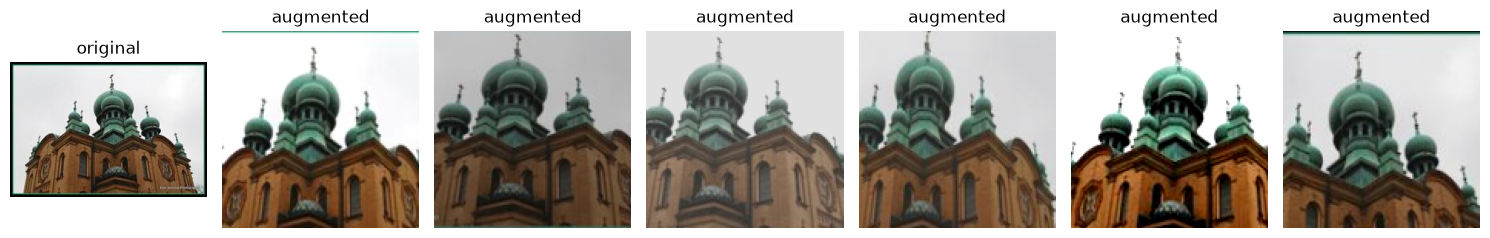

image width 234 | box before flip [[20, 30, 100, 120]] → after flip [[134, 30, 214, 120]]


In [11]:
sample_img, sample_label = imagenette_train[4000]                      # a real training image (PIL)
class_names = [c[0] for c in imagenette_train.classes]
print("label:", class_names[sample_label], "| size:", sample_img.size)

show_aug = v2.Compose([v2.ToImage(), v2.RandomResizedCrop(128, scale=(0.35, 1.0)), v2.RandomHorizontalFlip(),
                       v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3)])
torch.manual_seed(1)
fig, axes = plt.subplots(1, 7, figsize=(15, 2.6))
axes[0].imshow(sample_img)
axes[0].set_title("original")
for ax in axes[1:]:
    ax.imshow(show_aug(sample_img).permute(1, 2, 0))
    ax.set_title("augmented")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Boxes move with the image when they are tv_tensors
img_t = tv_tensors.Image(v2.functional.pil_to_tensor(sample_img))
boxes = tv_tensors.BoundingBoxes([[20, 30, 100, 120]], format="XYXY", canvas_size=img_t.shape[-2:])
flipped_img, flipped_boxes = v2.RandomHorizontalFlip(p=1.0)(img_t, boxes)
print(f"image width {img_t.shape[-1]} | box before flip {boxes.tolist()} → after flip {flipped_boxes.tolist()}")

The box's x-coordinates became `W − x`, exactly like the flip rule from the OpenCV notebook — without writing any box code.

> 💡 **Interview angle:** "What augmentations would you use for X?" — start from what does **not** change the label for that domain, apply them to training data only, and verify by *looking* at augmented batches. Mention stronger policies (RandAugment, TrivialAugment, MixUp/CutMix) for longer training, and that detection needs geometry-aware transforms.

## 7. Training a Small CNN From Scratch on CIFAR-10 🟡

**CIFAR-10**: 60,000 real 32×32 color photos in 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck) — 50,000 for training and 10,000 for testing.

The plan, done properly:

1. Carve a **validation split** (5,000 images) from the training set. We pick the best epoch on validation and touch the test set **once**.
2. Compute normalization **mean and std from our training split** — not from constants copied off the internet. (A widely copied std for CIFAR-10, `(0.2023, 0.1994, 0.2010)`, does not match the per-channel pixel std of the data; see Pitfalls.)
3. Augment training images only (random crop with 4-pixel reflect padding + horizontal flip).
4. Train a small VGG-style network with BatchNorm, AdamW, a one-cycle learning-rate schedule, and label smoothing.

We keep the uint8 images in memory and apply `transforms.v2` per sample inside a tiny `Dataset`; `num_workers=0` keeps it simple and notebook-friendly (worker processes need importable code on macOS/Windows).

In [12]:
CIFAR_CLASSES = cifar_train_full.classes
X_cifar = torch.from_numpy(cifar_train_full.data).permute(0, 3, 1, 2).contiguous()   # (50000, 3, 32, 32) uint8
y_cifar = torch.tensor(cifar_train_full.targets)
idx_tr, idx_va = train_test_split(np.arange(len(y_cifar)), test_size=5000, stratify=y_cifar.numpy(), random_state=SEED)


def channel_mean_std(images_uint8, chunk=2000):
    """Per-channel mean/std of a uint8 (N, C, H, W) tensor, in chunks to keep memory low."""
    total, total_sq, count = torch.zeros(3, dtype=torch.float64), torch.zeros(3, dtype=torch.float64), 0
    for i in range(0, len(images_uint8), chunk):
        x = images_uint8[i:i + chunk].to(torch.float64) / 255
        total += x.sum(dim=(0, 2, 3))
        total_sq += (x ** 2).sum(dim=(0, 2, 3))
        count += x.shape[0] * x.shape[2] * x.shape[3]
    mean = total / count
    return mean.tolist(), (total_sq / count - mean ** 2).sqrt().tolist()


CIFAR_MEAN, CIFAR_STD = channel_mean_std(X_cifar[idx_tr])
print("computed on our training split → mean", np.round(CIFAR_MEAN, 4), "std", np.round(CIFAR_STD, 4))


class TensorImageDataset(torch.utils.data.Dataset):
    """uint8 image tensors (N, 3, H, W) + labels, with a per-sample transform."""

    def __init__(self, images, labels, transform):
        self.images, self.labels, self.transform = images, labels, transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        return self.transform(self.images[i]), self.labels[i]


cifar_train_tf = v2.Compose([v2.RandomCrop(32, padding=4, padding_mode="reflect"), v2.RandomHorizontalFlip(),
                             v2.ToDtype(torch.float32, scale=True), v2.Normalize(CIFAR_MEAN, CIFAR_STD)])
cifar_eval_tf = v2.Compose([v2.ToDtype(torch.float32, scale=True), v2.Normalize(CIFAR_MEAN, CIFAR_STD)])
X_cifar_test = torch.from_numpy(cifar_test.data).permute(0, 3, 1, 2).contiguous()
y_cifar_test = torch.tensor(cifar_test.targets)

g = torch.Generator().manual_seed(SEED)
cifar_train_loader = torch.utils.data.DataLoader(TensorImageDataset(X_cifar[idx_tr], y_cifar[idx_tr], cifar_train_tf),
                                                 batch_size=256, shuffle=True, drop_last=True, generator=g)
cifar_val_loader = torch.utils.data.DataLoader(TensorImageDataset(X_cifar[idx_va], y_cifar[idx_va], cifar_eval_tf), batch_size=1000)
cifar_test_loader = torch.utils.data.DataLoader(TensorImageDataset(X_cifar_test, y_cifar_test, cifar_eval_tf), batch_size=1000)
print(f"train {len(idx_tr):,} | val {len(idx_va):,} | test {len(y_cifar_test):,} images")

computed on our training split → mean [0.4911 0.4821 0.4464] std [0.2469 0.2434 0.2616]
train 45,000 | val 5,000 | test 10,000 images


In [13]:
def conv_bn_relu(c_in, c_out, stride=1):
    return nn.Sequential(nn.Conv2d(c_in, c_out, 3, stride=stride, padding=1, bias=False),
                         nn.BatchNorm2d(c_out), nn.ReLU(inplace=True))


def small_cnn(num_classes=10, widths=(32, 64, 128), stem_stride=1, head_width=None, dropout=0.0):
    """VGG-style: [conv-bn-relu ×2 → max-pool] per width, then global average pooling and a linear head."""
    layers, c = [], 3
    for i, w in enumerate(widths):
        layers += [conv_bn_relu(c, w, stride=stem_stride if i == 0 else 1), conv_bn_relu(w, w), nn.MaxPool2d(2)]
        c = w
    if head_width:
        layers.append(conv_bn_relu(c, head_width))
        c = head_width
    layers += [nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(dropout), nn.Linear(c, num_classes)]
    return nn.Sequential(*layers)


def run_epoch(model, loader, optimizer=None, scheduler=None, label_smoothing=0.0):
    """One pass over `loader`. Trains if an optimizer is given; otherwise evaluates and also returns logits."""
    training = optimizer is not None
    model.train(training)
    loss_sum = torch.zeros((), device=DEVICE)
    correct = torch.zeros((), device=DEVICE, dtype=torch.long)
    seen, all_logits, all_labels = 0, [], []
    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = F.cross_entropy(logits, labels, label_smoothing=label_smoothing if training else 0.0)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()
            else:
                all_logits.append(logits.detach().float().cpu())
                all_labels.append(labels.cpu())
            loss_sum += loss.detach() * len(labels)
            correct += (logits.argmax(dim=1) == labels).sum()
            seen += len(labels)
    result = {"loss": loss_sum.item() / seen, "acc": correct.item() / seen}
    if not training:
        result["logits"], result["labels"] = torch.cat(all_logits), torch.cat(all_labels)
    return result


def fit(model, train_loader, val_loader, epochs, optimizer, scheduler, name, label_smoothing=0.1):
    """Train, keep the weights from the epoch with the best VALIDATION accuracy, and restore them at the end."""
    history, best_acc, best_epoch, best_state = [], -1.0, 0, None
    start_fit = time.perf_counter()
    for epoch in range(1, epochs + 1):
        t0 = time.perf_counter()
        tr = run_epoch(model, train_loader, optimizer, scheduler, label_smoothing)
        va = run_epoch(model, val_loader)
        history.append({"epoch": epoch, "train_loss": tr["loss"], "train_acc": tr["acc"], "val_loss": va["loss"], "val_acc": va["acc"]})
        if va["acc"] > best_acc:
            best_acc, best_epoch = va["acc"], epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"[{name}] epoch {epoch}/{epochs} | train loss {tr['loss']:.3f} acc {tr['acc']:.3f} | "
              f"val loss {va['loss']:.3f} acc {va['acc']:.3f} | {time.perf_counter() - t0:.1f}s")
    model.load_state_dict(best_state)
    seconds = time.perf_counter() - start_fit
    print(f"[{name}] best val acc {best_acc:.3f} at epoch {best_epoch} (weights restored) | total {seconds:.0f}s")
    return pd.DataFrame(history), seconds

small CNN: 288,746 parameters


[CIFAR-10] epoch 1/8 | train loss 1.721 acc 0.438 | val loss 1.285 acc 0.548 | 15.1s


[CIFAR-10] epoch 2/8 | train loss 1.367 acc 0.615 | val loss 1.088 acc 0.624 | 14.7s


[CIFAR-10] epoch 3/8 | train loss 1.192 acc 0.702 | val loss 1.095 acc 0.614 | 16.4s


[CIFAR-10] epoch 4/8 | train loss 1.082 acc 0.760 | val loss 0.795 acc 0.740 | 13.3s


[CIFAR-10] epoch 5/8 | train loss 1.015 acc 0.791 | val loss 0.678 acc 0.786 | 12.2s


[CIFAR-10] epoch 6/8 | train loss 0.953 acc 0.821 | val loss 0.558 acc 0.836 | 13.4s


[CIFAR-10] epoch 7/8 | train loss 0.905 acc 0.846 | val loss 0.510 acc 0.851 | 16.5s


[CIFAR-10] epoch 8/8 | train loss 0.880 acc 0.857 | val loss 0.489 acc 0.856 | 19.3s
[CIFAR-10] best val acc 0.856 at epoch 8 (weights restored) | total 121s


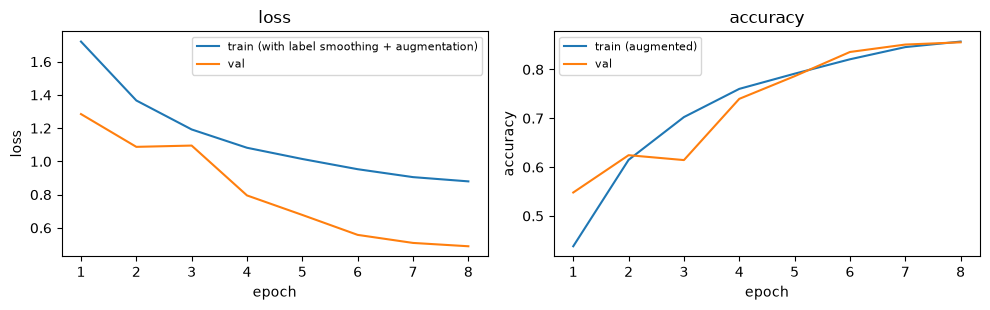

In [14]:
CIFAR_EPOCHS = 8
torch.manual_seed(SEED)
cifar_model = small_cnn().to(DEVICE)
print(f"small CNN: {n_params(cifar_model):,} parameters")
optimizer = torch.optim.AdamW(cifar_model.parameters(), lr=3e-3, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=3e-3, total_steps=CIFAR_EPOCHS * len(cifar_train_loader))
cifar_history, cifar_seconds = fit(cifar_model, cifar_train_loader, cifar_val_loader, CIFAR_EPOCHS, optimizer, scheduler, "CIFAR-10")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].plot(cifar_history["epoch"], cifar_history["train_loss"], label="train (with label smoothing + augmentation)")
axes[0].plot(cifar_history["epoch"], cifar_history["val_loss"], label="val")
axes[0].set(xlabel="epoch", ylabel="loss", title="loss")
axes[1].plot(cifar_history["epoch"], cifar_history["train_acc"], label="train (augmented)")
axes[1].plot(cifar_history["epoch"], cifar_history["val_acc"], label="val")
axes[1].set(xlabel="epoch", ylabel="accuracy", title="accuracy")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Training accuracy is measured on *augmented* images with BatchNorm in train mode, and the training loss includes label smoothing, so train and validation curves are not directly comparable — validation is the number to trust. Now the **one** evaluation on the test set:

In [15]:
cifar_test_result = run_epoch(cifar_model, cifar_test_loader)
print(f"CIFAR-10 TEST accuracy: {cifar_test_result['acc']:.3f}  (val was {cifar_history['val_acc'].max():.3f}; "
      f"{CIFAR_EPOCHS} epochs, {cifar_seconds:.0f}s on {DEVICE.type})")

CIFAR-10 TEST accuracy: 0.851  (val was 0.856; 8 epochs, 121s on mps)


> 💡 **Interview angle:** "Walk me through training an image classifier." — split train/val/test; compute normalization on train; augment train only; model with BatchNorm; AdamW + a warmup/decay schedule; checkpoint the best **validation** epoch; evaluate the test set once; then look at per-class errors. Mention what you'd do with more budget: more epochs, stronger augmentation, a ResNet, or transfer learning.

## 8. Evaluation: Confusion Matrix, Per-Class and Top-k Accuracy 🟢

One accuracy number hides *which* classes fail. Three standard tools:

- **Confusion matrix** — rows = true class, columns = predicted class; the diagonal holds correct predictions.
- **Per-class accuracy** (= per-class recall) — diagonal ÷ row sum.
- **Top-k accuracy** — the true label is among the model's k highest-scoring classes. ImageNet models report top-1 and top-5 because many classes are near-duplicates (e.g. dog breeds).

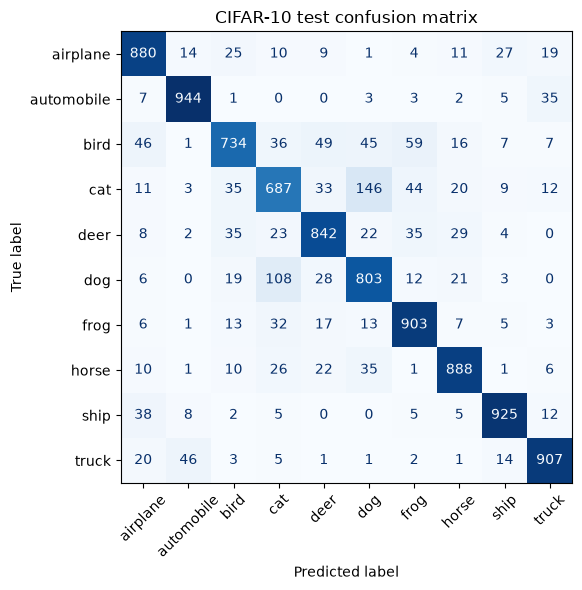

per-class accuracy (worst first):
 cat           0.687
bird          0.734
dog           0.803
deer          0.842
airplane      0.880
horse         0.888
frog          0.903
truck         0.907
ship          0.925
automobile    0.944
top-1 accuracy: 0.851
top-3 accuracy: 0.974
most common mistake: true 'cat' predicted as 'dog' (146 times)


In [16]:
test_logits, test_labels = cifar_test_result["logits"], cifar_test_result["labels"]
test_pred = test_logits.argmax(dim=1)
cm = confusion_matrix(test_labels, test_pred)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=CIFAR_CLASSES).plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title("CIFAR-10 test confusion matrix")
plt.tight_layout()
plt.show()

per_class = pd.Series(cm.diagonal() / cm.sum(axis=1), index=CIFAR_CLASSES).sort_values()
print("per-class accuracy (worst first):\n", per_class.round(3).to_string())

for k in (1, 3):
    topk_hit = (test_logits.topk(k, dim=1).indices == test_labels[:, None]).any(dim=1).float().mean()
    print(f"top-{k} accuracy: {topk_hit:.3f}")

off_diag = cm.copy()
np.fill_diagonal(off_diag, 0)
i, j = np.unravel_index(off_diag.argmax(), off_diag.shape)
print(f"most common mistake: true '{CIFAR_CLASSES[i]}' predicted as '{CIFAR_CLASSES[j]}' ({off_diag[i, j]} times)")

### ✍️ Your Turn

Compute **per-class accuracy** directly from the confusion matrix `cm` as a NumPy array in class order (not sorted). Store it in `per_class_acc`.

In [17]:
per_class_acc = None  # TODO
from sklearn.metrics import recall_score  # noqa: E402 — used only by the checker
check("per_class_acc", per_class_acc, recall_score(test_labels, test_pred, average=None),
      hint="The diagonal (np.diag) divided by the row sums (cm.sum(axis=1)).")

⏳ per_class_acc: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
per_class_acc = np.diag(cm) / cm.sum(axis=1)
from sklearn.metrics import recall_score
check("per_class_acc", per_class_acc, recall_score(test_labels, test_pred, average=None))
```

Per-class accuracy *is* per-class recall. Dividing by column sums instead would give per-class **precision**.
</details>

> 💡 **Interview angle:** "Accuracy is 86% — is the model good?" — compare with a baseline, look at the confusion matrix for systematic confusions (cat ↔ dog), check per-class recall for rare-but-important classes, and report top-k when classes are near-duplicates. For imbalanced data, use macro-averaged metrics.

## 9. Pretrained Weights and Their Preprocessing 🟡

torchvision ships pretrained models as **weights enums**, e.g. `models.ResNet18_Weights.IMAGENET1K_V1`. Each enum carries its own:

- `weights.transforms()` — the **exact inference preprocessing** the model was trained with (resize, crop, scale to 0..1, normalize with ImageNet mean/std),
- `weights.meta["categories"]` — the class names,
- `weights.meta["_metrics"]` — its reported accuracy.

The golden rule of transfer learning: **feed the network images that look like what it was trained on.** The old version of this notebook fed 32×32, un-normalized images into an ImageNet ResNet. Let's measure what that does, on two real photos.

In [18]:
weights = models.ResNet18_Weights.IMAGENET1K_V1
preprocess = weights.transforms()
IMAGENET_CATEGORIES = weights.meta["categories"]
IM_MEAN, IM_STD = list(preprocess.mean), list(preprocess.std)
print(preprocess)
print("ImageNet metrics:", weights.meta["_metrics"]["ImageNet-1K"], "| classes:", len(IMAGENET_CATEGORIES))

resnet = models.resnet18(weights=weights).eval().to(DEVICE)
photos = {"flower": Image.fromarray(load_sample_image("flower.jpg")), "china": Image.fromarray(load_sample_image("china.jpg"))}

variants = {
    "✅ weights.transforms()": lambda im: preprocess(im),
    "❌ 32×32, no normalization": v2.Compose([v2.ToImage(), v2.Resize((32, 32)), v2.ToDtype(torch.float32, scale=True)]),
    "❌ right size, no normalization": v2.Compose([v2.ToImage(), v2.Resize(256), v2.CenterCrop(224), v2.ToDtype(torch.float32, scale=True)]),
    "❌ channels swapped (BGR)": lambda im: preprocess(im)[[2, 1, 0]],
}
rows = []
for photo_name, photo in photos.items():
    for variant_name, tf in variants.items():
        with torch.inference_mode():
            probs = resnet(tf(photo).unsqueeze(0).to(DEVICE)).softmax(dim=1)[0].cpu()
        top_p, top_i = probs.topk(3)
        rows.append({"photo": photo_name, "preprocessing": variant_name,
                     "top-1": IMAGENET_CATEGORIES[top_i[0]], "p(top-1)": float(top_p[0]),
                     "top-3": ", ".join(IMAGENET_CATEGORIES[i] for i in top_i)})
print(pd.DataFrame(rows).to_string(index=False))

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)
ImageNet metrics: {'acc@1': 69.758, 'acc@5': 89.078} | classes: 1000


 photo                  preprocessing          top-1  p(top-1)                                   top-3
flower         ✅ weights.transforms()      honeycomb     0.663  honeycomb, hen-of-the-woods, stinkhorn
flower      ❌ 32×32, no normalization ping-pong ball     0.423 ping-pong ball, baseball, rubber eraser
flower ❌ right size, no normalization      honeycomb     0.961  honeycomb, stinkhorn, hen-of-the-woods
flower       ❌ channels swapped (BGR)      honeycomb     0.509             honeycomb, matchstick, coil
 china         ✅ weights.transforms()      bell cote     0.536            bell cote, palace, monastery
 china      ❌ 32×32, no normalization       lakeside     0.054              lakeside, geyser, ice bear
 china ❌ right size, no normalization      bell cote     0.288            bell cote, palace, monastery
 china       ❌ channels swapped (BGR)         palace     0.407               palace, boathouse, castle


Compare each wrong variant with the ✅ row for the same photo: the predicted classes and confidences change, sometimes completely. Nothing crashes — preprocessing bugs are *silent*.

### ✍️ Your Turn

Rebuild ResNet-18's evaluation preprocessing yourself with `transforms.v2`: resize the shorter side to 256, center-crop 224, convert to float in [0, 1], normalize with `IM_MEAN`/`IM_STD`. Store the `v2.Compose` in `my_preprocess`. The checker applies it to a uint8 tensor and compares with `weights.transforms()`.

In [19]:
flower_u8 = v2.functional.pil_to_tensor(photos["flower"])
my_preprocess = None  # TODO
check("my_preprocess", None if my_preprocess is None else my_preprocess(flower_u8), preprocess(flower_u8), atol=0.02,
      hint="v2.Compose([v2.Resize(256), v2.CenterCrop(224), v2.ToDtype(torch.float32, scale=True), v2.Normalize(IM_MEAN, IM_STD)])")

⏳ my_preprocess: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
flower_u8 = v2.functional.pil_to_tensor(photos["flower"])
my_preprocess = v2.Compose([
    v2.Resize(256),                          # shorter side → 256, keep aspect ratio
    v2.CenterCrop(224),
    v2.ToDtype(torch.float32, scale=True),   # 0..255 → 0..1
    v2.Normalize(IM_MEAN, IM_STD),
])
check("my_preprocess", my_preprocess(flower_u8), preprocess(flower_u8), atol=0.02)
```

The tolerance (0.02 after normalization ≈ one gray level) allows for rounding differences between torchvision's two resize implementations on `uint8` input. Writing the pipeline out once helps you spot mismatches when a deployment team reimplements preprocessing in another language.
</details>

> 💡 **Interview angle:** "Your pretrained model performs terribly on your data." — first check preprocessing parity with the weights: input size, RGB order, 0–1 scaling, mean/std normalization, interpolation. Use `weights.transforms()` rather than hand-copied constants, and write a test that runs one known image through training and serving code and compares tensors.

## 10. Transfer Learning Strategies 🔴

A pretrained backbone's early layers detect edges and textures that are useful for almost any image task; later layers are more specific to the original classes. That gives two main strategies:

| Strategy | What you train | When |
|---|---|---|
| **Feature extraction** (linear probe) | only a new head; the backbone is **frozen** (`requires_grad=False`, kept in `eval()`) | little data, or data similar to the pretraining data; fastest and cheapest |
| **Fine-tuning** | the head **and** the backbone, with a **lower learning rate** for the backbone (e.g. 10× lower) so its good features aren't destroyed | more data, or data that looks different from the pretraining data |
| Gradual unfreezing | head first, then later blocks, then everything | a middle ground when fine-tuning is unstable |

| | Similar to ImageNet | Very different (X-rays, satellites) |
|---|---|---|
| **Small dataset** | feature extraction | feature extraction from *earlier* layers, or careful fine-tuning with strong augmentation |
| **Large dataset** | fine-tune everything | fine-tune everything (or train from scratch) |

The mechanics:

In [20]:
tl_model = models.resnet18(weights=weights)
tl_model.fc = nn.Linear(tl_model.fc.in_features, 10)                # new head for 10 classes (random init)

for name, p in tl_model.named_parameters():                          # feature extraction: freeze all but the head
    p.requires_grad = name.startswith("fc.")
print(f"frozen backbone → trainable {n_params(tl_model, trainable_only=True):,} of {n_params(tl_model):,} parameters")

for p in tl_model.parameters():                                      # fine-tuning: everything trainable…
    p.requires_grad = True
backbone_params = [p for n, p in tl_model.named_parameters() if not n.startswith("fc.")]
optimizer_ft = torch.optim.AdamW([
    {"params": backbone_params, "lr": 1e-4},                         # …but the pretrained backbone moves slowly
    {"params": tl_model.fc.parameters(), "lr": 1e-3},                # …and the new head learns fast
], weight_decay=1e-4)
print("fine-tuning param groups:", [(len(g["params"]), g["lr"]) for g in optimizer_ft.param_groups])
del tl_model, optimizer_ft

frozen backbone → trainable 5,130 of 11,181,642 parameters
fine-tuning param groups: [(60, 0.0001), (2, 0.001)]


### ✍️ Your Turn

Load a ResNet-18 (random weights are fine for counting: `models.resnet18(weights=None)`), replace `fc` with a 5-class head, and **freeze everything except the head**. Store the number of trainable parameters in `trainable_after_freeze`.

In [21]:
trainable_after_freeze = None  # TODO
check("trainable_after_freeze", trainable_after_freeze, 2_565, hint="The head is Linear(512, 5): 512·5 weights + 5 biases.")

⏳ trainable_after_freeze: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
m = models.resnet18(weights=None)
m.fc = nn.Linear(m.fc.in_features, 5)
for name, p in m.named_parameters():
    p.requires_grad = name.startswith("fc.")
trainable_after_freeze = n_params(m, trainable_only=True)
check("trainable_after_freeze", trainable_after_freeze, 2_565)
```

Also remember to pass only trainable parameters (or all — frozen ones get no gradient) to the optimizer, and to keep frozen BatchNorm layers in `eval()` mode (Pitfall 4).
</details>

> 💡 **Interview angle:** "Fine-tune or freeze?" — depends on dataset size and similarity to the pretraining data; start with a linear probe as a strong, cheap baseline, then fine-tune with a 10× lower backbone learning rate, warmup, and early stopping on validation. Mention catastrophic forgetting and BatchNorm statistics with small batches.

## 11. Grad-CAM: Where Is the Model Looking? 🔴

**Grad-CAM** (Gradient-weighted Class Activation Mapping) produces a heatmap of the image regions that raised the score of a chosen class:

1. Run the image forward and keep the **activations** $A^k$ of the last convolutional stage (for ResNet: `layer4`, shape `(512, 7, 7)` at 224 px).
2. Backpropagate the **class score** $y^c$ (the logit, before softmax) to get gradients $\partial y^c / \partial A^k$.
3. Average each channel's gradient over space → one importance weight per channel: $\alpha_k = \text{mean}_{i,j}\, \partial y^c / \partial A^k_{ij}$.
4. Weighted sum of the activation maps, keep only positive evidence: $\text{CAM} = \text{ReLU}\left(\sum_k \alpha_k A^k\right)$; upsample to image size.

We capture activations and gradients with **hooks**: a forward hook on `layer4` stores its output and registers a tensor hook that stores the gradient flowing back into it.

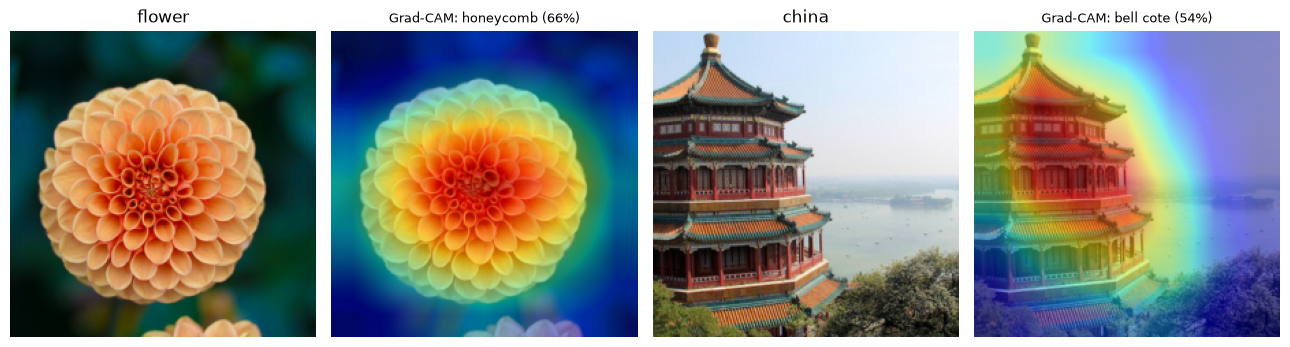

In [22]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model, self.activations, self.gradients = model, None, None
        self.handle = target_layer.register_forward_hook(self._forward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output.detach()
        output.register_hook(lambda grad: setattr(self, "gradients", grad.detach()))

    def __call__(self, images, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(images)
        if class_idx is None:
            class_idx = logits.argmax(dim=1)
        logits.gather(1, class_idx.view(-1, 1)).sum().backward()    # sum over the batch: each image's own class score
        alphas = self.gradients.mean(dim=(2, 3), keepdim=True)       # (N, K, 1, 1)
        cam = F.relu((alphas * self.activations).sum(dim=1))         # (N, h, w)
        cam = cam / (cam.amax(dim=(1, 2), keepdim=True) + 1e-8)      # scale each map to [0, 1]
        cam = F.interpolate(cam[:, None], size=images.shape[-2:], mode="bilinear", align_corners=False)[:, 0]
        return cam.detach(), logits.detach(), class_idx

    def remove(self):
        self.handle.remove()


def denormalize(x, mean=IM_MEAN, std=IM_STD):
    return (x.cpu() * torch.tensor(std)[:, None, None] + torch.tensor(mean)[:, None, None]).clamp(0, 1).permute(1, 2, 0)


cam_tool = GradCAM(resnet, resnet.layer4)
batch = torch.stack([preprocess(p) for p in photos.values()]).to(DEVICE)
cams, logits, cls = cam_tool(batch)
cam_tool.remove()

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
for n, name in enumerate(photos):
    prob = logits[n].softmax(0)[cls[n]].item()
    axes[2 * n].imshow(denormalize(batch[n]))
    axes[2 * n].set_title(f"{name}")
    axes[2 * n + 1].imshow(denormalize(batch[n]))
    axes[2 * n + 1].imshow(cams[n].cpu(), cmap="jet", alpha=0.45)
    axes[2 * n + 1].set_title(f"Grad-CAM: {IMAGENET_CATEGORIES[cls[n]]} ({prob:.0%})", fontsize=9)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

Grad-CAM is coarse (7×7 cells stretched over the image) and only shows *where* evidence came from, not *why*. It is great for spotting **shortcut learning** — e.g. a "boat" classifier that looks at water — and we'll use it on correct and wrong predictions in the mini project. The Build It From Scratch section re-implements it without hooks and runs sanity checks.

> 💡 **Interview angle:** "How would you debug what a CNN is looking at?" — Grad-CAM on the last conv layer for correct and incorrect examples, looking for shortcuts (backgrounds, watermarks, rulers in medical images). Mention its limits: low resolution, can look plausible even for a broken model — so run sanity checks (randomized weights should change the map).

## 12. Exporting and Measuring Inference Speed 🟡

Before serving a model you need:

1. **Inference mode** — `model.eval()` (BatchNorm/Dropout behaviour) and `torch.inference_mode()` (no autograd bookkeeping).
2. **An exported artifact** — `torch.export.export(model, example_inputs, dynamic_shapes=...)` traces the model into a clean graph of standard operators (an `ExportedProgram`) that can be saved to a `.pt2` file, loaded without your Python class, and lowered to runtimes like AOTInductor, ExecuTorch (mobile), or ONNX (`torch.onnx.export(..., dynamo=True)` builds on the same machinery). `dynamic_shapes` marks dimensions (like batch size) that may vary.
3. **Honest measurements** — warm up first; on a GPU **synchronize** before reading the clock (GPU calls return immediately and run asynchronously); report **latency percentiles** (p50, p95) at batch size 1 *and* **throughput** (images/second) at a realistic batch size.

In [23]:
export_model = models.resnet18(weights=weights).eval()                 # CPU copy for export
batch_dim = torch.export.Dim("batch", min=1, max=256)
start = time.perf_counter()
exported = torch.export.export(export_model, (torch.randn(2, 3, 224, 224),), dynamic_shapes={"x": {0: batch_dim}})
export_path = OUTPUT_DIR / "resnet18_imagenet.pt2"
torch.export.save(exported, export_path)
loaded_program = torch.export.load(export_path).module()
print(f"exported in {time.perf_counter() - start:.1f}s | graph has {len(list(exported.graph.nodes))} nodes | "
      f"file {export_path.stat().st_size / 1e6:.1f} MB")

check_batch = torch.randn(5, 3, 224, 224)                              # a batch size never seen during export
with torch.inference_mode():
    max_diff = (loaded_program(check_batch) - export_model(check_batch)).abs().max().item()
print(f"loaded .pt2 vs eager model on batch of 5: max |difference| = {max_diff:.2e}")
assert max_diff < 1e-4


def measure(fn, batch, device, repeats=30, warmup=5):
    """Latency percentiles (ms per call) and throughput (images/s), synchronizing the GPU correctly."""
    batch = batch.to(device)
    with torch.inference_mode():
        for _ in range(warmup):
            fn(batch)
        if device.type != "cpu":
            sync()
        times = []
        for _ in range(repeats):
            t0 = time.perf_counter()
            fn(batch)
            if device.type != "cpu":
                sync()
            times.append(time.perf_counter() - t0)
    times_ms = np.array(times) * 1000
    return {"p50 ms": np.percentile(times_ms, 50), "p95 ms": np.percentile(times_ms, 95),
            "images/s": len(batch) / (times_ms.mean() / 1000)}


cpu = torch.device("cpu")
rows = [
    {"setup": "CPU eager, batch 1", **measure(export_model, torch.randn(1, 3, 224, 224), cpu)},
    {"setup": "CPU exported .pt2, batch 1", **measure(loaded_program, torch.randn(1, 3, 224, 224), cpu)},
    {"setup": "CPU eager, batch 32", **measure(export_model, torch.randn(32, 3, 224, 224), cpu, repeats=10)},
]
if DEVICE.type != "cpu":
    rows += [{"setup": f"{DEVICE.type.upper()} eager, batch 1", **measure(resnet, torch.randn(1, 3, 224, 224), DEVICE)},
             {"setup": f"{DEVICE.type.upper()} eager, batch 32", **measure(resnet, torch.randn(32, 3, 224, 224), DEVICE, repeats=10)}]
else:
    print("⏭️ Skipped GPU rows: no GPU available on this machine.")
speed_df = pd.DataFrame(rows).set_index("setup")
print(speed_df.round(2).to_string())
best_single = speed_df["p50 ms"].idxmin()
best_throughput = speed_df["images/s"].idxmax()
print(f"\nlowest single-image latency: {best_single} | highest throughput: {best_throughput}")
print(f"CPU: exported vs eager at batch 1 → {speed_df.loc['CPU eager, batch 1', 'p50 ms'] / speed_df.loc['CPU exported .pt2, batch 1', 'p50 ms']:.2f}× speed | "
      f"batch 32 vs 1 throughput → {speed_df.loc['CPU eager, batch 32', 'images/s'] / speed_df.loc['CPU eager, batch 1', 'images/s']:.1f}×")
if DEVICE.type != "cpu":
    gpu = DEVICE.type.upper()
    print(f"{gpu}: batch 32 vs 1 throughput → {speed_df.loc[f'{gpu} eager, batch 32', 'images/s'] / speed_df.loc[f'{gpu} eager, batch 1', 'images/s']:.1f}× "
          f"(but each batch-32 call takes {speed_df.loc[f'{gpu} eager, batch 32', 'p50 ms']:.0f} ms)")

exported in 1.6s | graph has 193 nodes | file 48.2 MB
loaded .pt2 vs eager model on batch of 5: max |difference| = 0.00e+00


                            p50 ms   p95 ms  images/s
setup                                                
CPU eager, batch 1           25.09    31.16     38.42
CPU exported .pt2, batch 1   25.62    38.67     34.55
CPU eager, batch 32         830.44  1123.59     36.30
MPS eager, batch 1            4.66     9.44    172.54
MPS eager, batch 32          42.40    44.39    772.24

lowest single-image latency: MPS eager, batch 1 | highest throughput: MPS eager, batch 32
CPU: exported vs eager at batch 1 → 0.98× speed | batch 32 vs 1 throughput → 0.9×
MPS: batch 32 vs 1 throughput → 4.5× (but each batch-32 call takes 42 ms)


Read the ratios above rather than trusting rules of thumb. Typically a GPU gains much more from batching than a CPU does, and batching always raises the time each call takes. Exporting is mainly about **portability** (a graph without your Python code); the big speedups come from what you do with that graph — compilation, quantization, specialized runtimes. On a laptop shared with other programs, timings also vary from run to run, so repeat measurements before drawing fine-grained conclusions.

> 💡 **Interview angle:** "How do you benchmark a model for production?" — fixed input shapes, warmup, synchronize GPU, many repeats, report p50/p95/p99 latency at batch 1 and throughput at the serving batch size, on the target hardware, **including preprocessing**. Then optimize: smaller model, export + compile, quantization (int8), dynamic batching.

## 🔧 Build It From Scratch

### 1) `conv2d` with `unfold` (im2col)

Real frameworks don't slide kernels in Python loops. **im2col** copies every k×k patch into a column (`F.unfold` → shape `(N, C·k·k, L)` with L output positions); then the whole convolution is **one matrix multiplication** with the flattened kernels `(C_out, C·k·k)`, followed by a reshape. That's why convolutions run fast on GPUs.

In [24]:
def conv2d_unfold(x, weight, bias=None, stride=1, padding=0, dilation=1):
    n, c_in, h, w = x.shape
    c_out, _, kh, kw = weight.shape
    cols = F.unfold(x, (kh, kw), dilation=dilation, padding=padding, stride=stride)   # (N, C·kh·kw, L)
    out = weight.view(c_out, -1) @ cols                                               # (N, C_out, L)
    if bias is not None:
        out = out + bias.view(1, -1, 1)
    h_out = conv_output_size(h, kh, stride, padding, dilation)
    w_out = conv_output_size(w, kw, stride, padding, dilation)
    return out.view(n, c_out, h_out, w_out)


torch.manual_seed(0)
x = torch.randn(2, 3, 17, 19, dtype=torch.float64)
weight = torch.randn(8, 3, 3, 5, dtype=torch.float64)                                 # non-square on purpose
bias = torch.randn(8, dtype=torch.float64)
for stride, padding, dilation in [(1, 0, 1), (1, 1, 1), (2, 1, 1), (2, 2, 2), (3, 0, 1)]:
    ours = conv2d_unfold(x, weight, bias, stride, padding, dilation)
    reference = F.conv2d(x, weight, bias, stride=stride, padding=padding, dilation=dilation)
    assert ours.shape == reference.shape and torch.allclose(ours, reference)
    print(f"✅ stride={stride} padding={padding} dilation={dilation} → {tuple(ours.shape)} matches F.conv2d")

✅ stride=1 padding=0 dilation=1 → (2, 8, 15, 15) matches F.conv2d
✅ stride=1 padding=1 dilation=1 → (2, 8, 17, 17) matches F.conv2d
✅ stride=2 padding=1 dilation=1 → (2, 8, 9, 9) matches F.conv2d
✅ stride=2 padding=2 dilation=2 → (2, 8, 9, 8) matches F.conv2d
✅ stride=3 padding=0 dilation=1 → (2, 8, 5, 5) matches F.conv2d


### 2) Grad-CAM without hooks, plus sanity checks

Split ResNet-18's forward pass by hand into **features** (up to `layer4`) and **head** (pool + fc). Then `torch.autograd.grad` gives the gradient of the class score with respect to the features directly. It must equal the hook-based version from section 11.

A saliency method is only useful if it depends on what the model learned. The **model randomization test** (Adebayo et al., 2018): re-initialize `layer4`'s weights — the heatmap should change a lot. We also check that the explanation is (approximately) **flip-consistent**: the map of a mirrored image, mirrored back, should resemble the original map.

In [25]:
def resnet_features(m, x):
    x = m.maxpool(m.relu(m.bn1(m.conv1(x))))
    return m.layer4(m.layer3(m.layer2(m.layer1(x))))


def resnet_head(m, feats):
    return m.fc(torch.flatten(m.avgpool(feats), 1))


def gradcam_from_scratch(m, image, class_idx=None):
    feats = resnet_features(m, image)                                   # (1, 512, 7, 7), part of the autograd graph
    logits = resnet_head(m, feats)
    class_idx = int(logits.argmax()) if class_idx is None else class_idx
    (grads,) = torch.autograd.grad(logits[0, class_idx], feats)
    cam = F.relu((grads.mean(dim=(2, 3), keepdim=True) * feats).sum(dim=1))
    cam = cam / (cam.amax() + 1e-8)
    return F.interpolate(cam[:, None], size=image.shape[-2:], mode="bilinear", align_corners=False)[0, 0].detach(), logits.detach(), class_idx


flower_batch = batch[:1]
cam_scratch, logits_scratch, cls_scratch = gradcam_from_scratch(resnet, flower_batch)
with torch.no_grad():
    assert torch.allclose(logits_scratch, resnet(flower_batch), atol=1e-3)     # the manual split is the same network
assert cls_scratch == int(cls[0])
assert torch.allclose(cam_scratch, cams[0], atol=1e-3)                          # float32 on GPU: allow tiny rounding
print("✅ hook-free Grad-CAM matches the hook-based GradCAM class")


def corr(a, b):
    return float(np.corrcoef(a.flatten().cpu().numpy(), b.flatten().cpu().numpy())[0, 1])


cam_flip, _, _ = gradcam_from_scratch(resnet, torch.flip(flower_batch, dims=[3]), cls_scratch)
randomized = copy.deepcopy(resnet)
torch.manual_seed(0)
for module in randomized.layer4.modules():
    if isinstance(module, nn.Conv2d):
        nn.init.kaiming_normal_(module.weight)
cam_random, _, _ = gradcam_from_scratch(randomized, flower_batch, cls_scratch)
flip_corr, random_corr = corr(cam_scratch, torch.flip(cam_flip, dims=[1])), corr(cam_scratch, cam_random)
print(f"correlation with flipped-image map (flipped back): {flip_corr:.3f}")
print(f"correlation with map from randomized layer4      : {random_corr:.3f}")
print("✅ sanity check passed: the map depends on the learned weights" if random_corr < flip_corr
      else "⚠️ sanity check failed: map barely depends on the learned weights")
del randomized
free_memory()

✅ hook-free Grad-CAM matches the hook-based GradCAM class
correlation with flipped-image map (flipped back): 0.969
correlation with map from randomized layer4      : 0.409
✅ sanity check passed: the map depends on the learned weights


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Forgetting `model.eval()`

In train mode BatchNorm normalizes with the current batch's statistics, so a prediction depends on *which other images* are in the batch — and every forward pass silently updates the running statistics. We use a copy of the CIFAR model so the real one isn't modified.

In [26]:
probe_model = copy.deepcopy(cifar_model)
images16 = torch.stack([cifar_eval_tf(X_cifar[i]) for i in idx_va[:16]]).to(DEVICE)
with torch.no_grad():
    probe_model.eval()
    logits_eval = probe_model(images16)
    probe_model.train()                                     # ❌ left in train mode
    logits_train_16 = probe_model(images16)
    logits_train_4 = probe_model(images16[:4])               # same first 4 images, different batch
print(f"❌ train mode vs eval mode: {(logits_eval.argmax(1) != logits_train_16.argmax(1)).sum().item()} of 16 predicted classes differ")
print(f"❌ train mode, first 4 images scored alone vs inside the batch of 16: logits differ by up to "
      f"{(logits_train_16[:4] - logits_train_4).abs().max().item():.3f} — the output depends on the other images in the batch")
print("✅ always call model.eval() (and use torch.inference_mode()) for validation, testing, and serving")
del probe_model

❌ train mode vs eval mode: 2 of 16 predicted classes differ
❌ train mode, first 4 images scored alone vs inside the batch of 16: logits differ by up to 1.634 — the output depends on the other images in the batch
✅ always call model.eval() (and use torch.inference_mode()) for validation, testing, and serving


### ❌ Pitfall 2 — Copying normalization constants instead of computing them

In [27]:
COPIED_STD = (0.2023, 0.1994, 0.2010)                       # ❌ widely copied, doesn't match the data
sample = X_cifar[idx_tr[:5000]].float() / 255
for name, std in [("❌ copied std", COPIED_STD), ("✅ computed std", CIFAR_STD)]:
    normalized = (sample - torch.tensor(CIFAR_MEAN)[:, None, None]) / torch.tensor(std)[:, None, None]
    print(f"{name:15s} → per-channel std after normalizing: {normalized.std(dim=(0, 2, 3)).numpy().round(3)} (target 1.0)")

❌ copied std    → per-channel std after normalizing: [1.213 1.213 1.29 ] (target 1.0)
✅ computed std  → per-channel std after normalizing: [0.994 0.994 0.991] (target 1.0)


The damage from slightly-off constants is usually small for a model trained *with* them — but it's a sign of untested preprocessing, and it becomes a real bug when training and serving code use different constants.

### ❌ Pitfall 3 — Augmenting the validation or test set

In [28]:
aug_val_loader = torch.utils.data.DataLoader(TensorImageDataset(X_cifar[idx_va], y_cifar[idx_va], cifar_train_tf), batch_size=1000)
torch.manual_seed(1)
acc_aug_1 = run_epoch(cifar_model, aug_val_loader)["acc"]
torch.manual_seed(2)
acc_aug_2 = run_epoch(cifar_model, aug_val_loader)["acc"]
acc_clean = run_epoch(cifar_model, cifar_val_loader)["acc"]
print(f"❌ val accuracy with random train-time augmentation: {acc_aug_1:.3f}, then {acc_aug_2:.3f} (changes every run)")
print(f"✅ val accuracy with deterministic eval transform  : {acc_clean:.3f}")

❌ val accuracy with random train-time augmentation: 0.849, then 0.840 (changes every run)
✅ val accuracy with deterministic eval transform  : 0.856


### ❌ Pitfall 4 — "Frozen" backbone whose BatchNorm is still in train mode

`requires_grad=False` stops *gradients*, but BatchNorm's running statistics are updated by any forward pass in train mode — so the "frozen" backbone still changes.

In [29]:
frozen = models.resnet18(weights=weights).to(DEVICE)
for p in frozen.parameters():
    p.requires_grad = False
before = frozen.bn1.running_mean.clone()
some_images = torch.stack([cifar_eval_tf(X_cifar[i]) for i in idx_tr[:64]]).to(DEVICE)
frozen.train()                                                        # ❌ e.g. model.train() called on the whole model
with torch.no_grad():
    frozen(F.interpolate(some_images, size=160, mode="bilinear", align_corners=False))
print(f"❌ train mode: bn1.running_mean changed by up to {(frozen.bn1.running_mean - before).abs().max().item():.4f}")

frozen = models.resnet18(weights=weights).to(DEVICE).eval()          # ✅ frozen backbone stays in eval mode
before = frozen.bn1.running_mean.clone()
with torch.no_grad():
    frozen(F.interpolate(some_images, size=160, mode="bilinear", align_corners=False))
print(f"✅ eval mode : bn1.running_mean changed by {(frozen.bn1.running_mean - before).abs().max().item():.4f}")
del frozen
free_memory()

❌ train mode: bn1.running_mean changed by up to 0.0161


✅ eval mode : bn1.running_mean changed by 0.0000


### ❌ Pitfall 5 — Timing GPU code without synchronizing

In [30]:
if DEVICE.type == "cpu":
    print("⏭️ Skipped: on CPU every call is synchronous, so this pitfall doesn't apply.")
else:
    big_batch = torch.randn(64, 3, 224, 224, device=DEVICE)
    with torch.inference_mode():
        for _ in range(3):
            resnet(big_batch)
        sync()
        t0 = time.perf_counter()
        resnet(big_batch)                                           # ❌ returns before the GPU is done
        no_sync_ms = (time.perf_counter() - t0) * 1000
        sync()
        t0 = time.perf_counter()
        resnet(big_batch)
        sync()                                                      # ✅ wait for the GPU
        sync_ms = (time.perf_counter() - t0) * 1000
    print(f"❌ without synchronize: {no_sync_ms:.2f} ms | ✅ with synchronize: {sync_ms:.2f} ms for a batch of 64")
    del big_batch

❌ without synchronize: 2.97 ms | ✅ with synchronize: 69.05 ms for a batch of 64


### ❌ Pitfall 6 — `ToDtype(float32)` without `scale=True`

In [31]:
flower_tensor = v2.functional.pil_to_tensor(photos["flower"])
bad_tf = v2.Compose([v2.Resize(256), v2.CenterCrop(224), v2.ToDtype(torch.float32), v2.Normalize(IM_MEAN, IM_STD)])            # ❌
good_tf = v2.Compose([v2.Resize(256), v2.CenterCrop(224), v2.ToDtype(torch.float32, scale=True), v2.Normalize(IM_MEAN, IM_STD)])  # ✅
for name, tf in [("❌ no scale", bad_tf), ("✅ scale=True", good_tf)]:
    x = tf(flower_tensor)
    with torch.inference_mode():
        p, i = resnet(x.unsqueeze(0).to(DEVICE)).softmax(1)[0].max(0)
    print(f"{name:13s} input range [{x.min():7.1f}, {x.max():7.1f}] → top-1 '{IMAGENET_CATEGORIES[i]}' ({p:.1%})")

❌ no scale    input range [   -2.1,  1085.2] → top-1 'dishwasher' (97.9%)
✅ scale=True  input range [   -2.1,     2.1] → top-1 'honeycomb' (66.3%)


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Output sizes by formula
For a 64×64 input, compute the output spatial size of each layer config `(kernel, stride, padding, dilation)` in `layer_specs` **using the formula** (not by running layers). Store a list of ints in `sizes`.

In [32]:
layer_specs = [(3, 1, 1, 1), (5, 2, 2, 1), (3, 2, 0, 1), (3, 1, 2, 2), (7, 3, 3, 1)]
sizes = None  # TODO
check("sizes", sizes, [nn.Conv2d(1, 1, k, stride=s, padding=p, dilation=d)(torch.zeros(1, 1, 64, 64)).shape[-1] for k, s, p, d in layer_specs],
      hint="(n + 2p - d(k-1) - 1) // s + 1 for each spec.")

⏳ sizes: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
layer_specs = [(3, 1, 1, 1), (5, 2, 2, 1), (3, 2, 0, 1), (3, 1, 2, 2), (7, 3, 3, 1)]
sizes = [(64 + 2 * p - d * (k - 1) - 1) // s + 1 for k, s, p, d in layer_specs]
check("sizes", sizes, [nn.Conv2d(1, 1, k, stride=s, padding=p, dilation=d)(torch.zeros(1, 1, 64, 64)).shape[-1] for k, s, p, d in layer_specs])
```
→ `[64, 32, 31, 64, 22]`. Note `(3, 1, 2, 2)` keeps the size: a dilated 3×3 covers 5×5, so it needs padding 2.
</details>

### 🟢 Exercise 2 — Parameters of a conv layer
Without building the layer, compute the number of parameters of `nn.Conv2d(64, 128, kernel_size=3)` (bias included). Store an `int` in `conv_params`.

In [33]:
conv_params = None  # TODO
check("conv_params", conv_params, n_params(nn.Conv2d(64, 128, kernel_size=3)), hint="C_out · C_in · k · k + C_out")

⏳ conv_params: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
conv_params = 128 * 64 * 3 * 3 + 128      # 73,728 weights + 128 biases
check("conv_params", conv_params, n_params(nn.Conv2d(64, 128, kernel_size=3)))
```
</details>

### 🟢 Exercise 3 — Normalize an image tensor by hand
`img01` is a float image in [0, 1] with shape `(3, H, W)`. Normalize each channel with `IM_MEAN` and `IM_STD` using **broadcasting** (no `v2.Normalize`). Store the result in `normalized_img`.

In [34]:
img01 = v2.functional.pil_to_tensor(photos["china"]).float() / 255
normalized_img = None  # TODO
check("normalized_img", normalized_img, v2.Normalize(IM_MEAN, IM_STD)(img01), atol=1e-5,
      hint="torch.tensor(IM_MEAN) has shape (3,); reshape it to (3, 1, 1) so it broadcasts over H and W.")

⏳ normalized_img: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
img01 = v2.functional.pil_to_tensor(photos["china"]).float() / 255
mean = torch.tensor(IM_MEAN).view(3, 1, 1)
std = torch.tensor(IM_STD).view(3, 1, 1)
normalized_img = (img01 - mean) / std
check("normalized_img", normalized_img, v2.Normalize(IM_MEAN, IM_STD)(img01), atol=1e-5)
```
Without the reshape, `(3,)` would broadcast against the **width** axis — a silent shape bug (or an error when W ≠ 3).
</details>

### 🟡 Exercise 4 — Top-k accuracy
Write `topk_accuracy(logits, targets, k)` for a `(N, C)` logits tensor and `(N,)` targets, returning a Python float.

In [35]:
def topk_accuracy(logits, targets, k):
    return None  # TODO


_g = torch.Generator().manual_seed(0)
_logits = torch.randn(200, 10, generator=_g)
_targets = torch.randint(0, 10, (200,), generator=_g)
_result = topk_accuracy(_logits, _targets, 3)
check("topk_accuracy", _result, top_k_accuracy_score(_targets.numpy(), _logits.numpy(), k=3, labels=np.arange(10)),
      hint="logits.topk(k, dim=1).indices has shape (N, k); compare with targets[:, None] and use .any(dim=1).")

⏳ topk_accuracy: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def topk_accuracy(logits, targets, k):
    topk = logits.topk(k, dim=1).indices                 # (N, k)
    return (topk == targets[:, None]).any(dim=1).float().mean().item()

_g = torch.Generator().manual_seed(0)
_logits = torch.randn(200, 10, generator=_g)
_targets = torch.randint(0, 10, (200,), generator=_g)
_result = topk_accuracy(_logits, _targets, 3)
check("topk_accuracy", _result, top_k_accuracy_score(_targets.numpy(), _logits.numpy(), k=3, labels=np.arange(10)))
```
</details>

### 🟡 Exercise 5 — Depthwise-separable convolution
MobileNet and EfficientNet replace a standard 3×3 conv with a **depthwise** 3×3 conv (`groups=C_in`, one filter per channel) followed by a **pointwise** 1×1 conv that mixes channels. Build `depthwise_separable(c_in, c_out)` as an `nn.Sequential` of those two convs (both `bias=False`, padding 1 on the 3×3). The checker verifies the parameter count and output shape for 64 → 128 channels.

In [36]:
def depthwise_separable(c_in, c_out):
    return None  # TODO


_ds = depthwise_separable(64, 128)
check("depthwise_separable", None if _ds is None else (n_params(_ds), tuple(_ds(torch.zeros(2, 64, 32, 32)).shape)),
      (64 * 9 + 64 * 128, (2, 128, 32, 32)), hint="nn.Conv2d(c_in, c_in, 3, padding=1, groups=c_in, bias=False), then nn.Conv2d(c_in, c_out, 1, bias=False).")

⏳ depthwise_separable: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def depthwise_separable(c_in, c_out):
    return nn.Sequential(
        nn.Conv2d(c_in, c_in, 3, padding=1, groups=c_in, bias=False),   # spatial filtering, per channel
        nn.Conv2d(c_in, c_out, 1, bias=False),                          # channel mixing
    )

_ds = depthwise_separable(64, 128)
check("depthwise_separable", (n_params(_ds), tuple(_ds(torch.zeros(2, 64, 32, 32)).shape)), (64 * 9 + 64 * 128, (2, 128, 32, 32)))
print(f"standard 3×3 conv: {n_params(nn.Conv2d(64, 128, 3, bias=False)):,} params vs separable: {n_params(_ds):,}")
```
8,768 vs 73,728 parameters — about 8× fewer (and similarly fewer multiply-adds), usually for a small accuracy cost.
</details>

### 🔴 Exercise 6 — A ResNet basic block with downsampling (interview classic)
Implement `MyBasicBlock(c_in, c_out, stride)`: `conv3×3(stride) → BN → ReLU → conv3×3 → BN`, plus a shortcut that is the identity when shapes match, otherwise `conv1×1(stride) → BN`; output = `ReLU(main + shortcut)`. Convs use `bias=False`. It must produce the same output shape and parameter count as torchvision's `BasicBlock` for 64 → 128 channels with stride 2.

In [37]:
class MyBasicBlock(nn.Module):
    def __init__(self, c_in, c_out, stride=1):
        super().__init__()
        self.todo = True  # TODO: define layers

    def forward(self, x):
        return None  # TODO


from torchvision.models.resnet import BasicBlock  # noqa: E402
_ref_block = BasicBlock(64, 128, stride=2, downsample=nn.Sequential(nn.Conv2d(64, 128, 1, stride=2, bias=False), nn.BatchNorm2d(128)))
_mine = MyBasicBlock(64, 128, stride=2)
_out = _mine(torch.randn(2, 64, 32, 32))
check("MyBasicBlock", None if _out is None else (tuple(_out.shape), n_params(_mine)), ((2, 128, 16, 16), n_params(_ref_block)),
      hint="Use a flag like `self.shortcut = nn.Identity()` when stride == 1 and c_in == c_out.")

⏳ MyBasicBlock: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
class MyBasicBlock(nn.Module):
    def __init__(self, c_in, c_out, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(c_in, c_out, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c_out)
        self.conv2 = nn.Conv2d(c_out, c_out, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c_out)
        if stride == 1 and c_in == c_out:
            self.shortcut = nn.Identity()
        else:
            self.shortcut = nn.Sequential(nn.Conv2d(c_in, c_out, 1, stride=stride, bias=False), nn.BatchNorm2d(c_out))

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x))

from torchvision.models.resnet import BasicBlock
_ref_block = BasicBlock(64, 128, stride=2, downsample=nn.Sequential(nn.Conv2d(64, 128, 1, stride=2, bias=False), nn.BatchNorm2d(128)))
_mine = MyBasicBlock(64, 128, stride=2)
_out = _mine(torch.randn(2, 64, 32, 32))
check("MyBasicBlock", (tuple(_out.shape), n_params(_mine)), ((2, 128, 16, 16), n_params(_ref_block)))
```
Follow-ups: why `bias=False` (BatchNorm's β makes it redundant), where the ReLU goes (after the addition), and the *bottleneck* block (1×1 → 3×3 → 1×1) used in ResNet-50+.
</details>

## 🚀 Mini Project: Scratch vs Frozen vs Fine-Tuned on Imagenette

**Goal:** on a real 10-class image dataset, compare three ways to build a classifier under the same laptop budget, with a fair, leak-free protocol:

- **(a) From scratch** — the small CNN from section 7 (adapted to larger images), random initialization.
- **(b) Frozen backbone + linear head** — ImageNet-pretrained ResNet-18 as a fixed feature extractor.
- **(c) Fine-tuning** — the same ResNet-18, all layers trained, backbone learning rate 10× lower than the head's.

**Dataset:** [Imagenette](https://github.com/fastai/imagenette) (160px version) — 10 easily told-apart ImageNet classes: tench, English springer, cassette player, chain saw, church, French horn, garbage truck, gas pump, golf ball, parachute.

**Protocol:** carve a stratified **validation split (15%)** from the official training set for every choice (epochs, resolution); use the official **val split only once, as the test set**, at the very end.

⚠️ **Honesty note:** Imagenette's images come from ImageNet, and ResNet-18 was pretrained on ImageNet's training set *including these 10 classes*. So (b) and (c) have a head start that you would not get on, say, X-rays. We measure how big that effect might be in Step 6.

### Step 1 — Decode the images once into uint8 tensors

In [38]:
def load_imagenette_split(split, dataset, size=160):
    """Decode every JPEG of a split into a (N, 3, size, size) uint8 tensor (resize shorter side + center crop)."""
    files = sorted((DATA_DIR / "imagenette2-160" / split).glob("*/*.JPEG"))
    assert len(files) == len(dataset), (len(files), len(dataset))
    prep = v2.Compose([v2.ToImage(), v2.Resize(size), v2.CenterCrop(size)])
    images = torch.empty((len(files), 3, size, size), dtype=torch.uint8)
    labels = torch.empty(len(files), dtype=torch.long)
    for i, path in enumerate(files):
        with Image.open(path) as im:
            images[i] = prep(im.convert("RGB"))
        labels[i] = dataset.wnid_to_idx[path.parent.name]
    return images, labels, [f.name for f in files]


start = time.perf_counter()
X_net, y_net, _ = load_imagenette_split("train", imagenette_train)
X_net_test, y_net_test, test_files = load_imagenette_split("val", imagenette_val)
print(f"decoded {len(X_net) + len(X_net_test):,} images in {time.perf_counter() - start:.1f}s | "
      f"train tensor {X_net.nbytes / 1e6:.0f} MB, test tensor {X_net_test.nbytes / 1e6:.0f} MB")
print(pd.DataFrame({"train": np.bincount(y_net.numpy()), "test": np.bincount(y_net_test.numpy())}, index=class_names).T.to_string())

net_tr, net_va = train_test_split(np.arange(len(y_net)), test_size=0.15, stratify=y_net.numpy(), random_state=SEED)
X_net_tr, y_net_tr = X_net[net_tr], y_net[net_tr]
X_net_va, y_net_va = X_net[net_va], y_net[net_va]
print(f"\ntrain {len(y_net_tr):,} | validation {len(y_net_va):,} | test (official val, used once) {len(y_net_test):,}")

del X_net, X_cifar, X_cifar_test, cifar_train_loader, cifar_val_loader, cifar_test_loader, aug_val_loader   # free memory
free_memory()

decoded 13,394 images in 5.9s | train tensor 727 MB, test tensor 301 MB
       tench  English springer  cassette player  chain saw  church  French horn  garbage truck  gas pump  golf ball  parachute
train    963               955              993        858     941          956            961       931        951        960
test     387               395              357        386     409          394            389       419        399        390

train 8,048 | validation 1,421 | test (official val, used once) 3,925


### Step 2 — (a) Small CNN from scratch

128×128 random-resized crops (a smaller input keeps the from-scratch model within budget), a stride-2 stem, normalization computed on our training split.

In [39]:
SCRATCH_EPOCHS = 10
NET_MEAN, NET_STD = channel_mean_std(X_net_tr)
scratch_train_tf = v2.Compose([v2.RandomResizedCrop(128, scale=(0.35, 1.0)), v2.RandomHorizontalFlip(),
                               v2.ToDtype(torch.float32, scale=True), v2.Normalize(NET_MEAN, NET_STD)])
scratch_eval_tf = v2.Compose([v2.Resize(128), v2.ToDtype(torch.float32, scale=True), v2.Normalize(NET_MEAN, NET_STD)])


def make_loaders(train_tf, eval_tf, batch_size):
    g_loader = torch.Generator().manual_seed(SEED)
    return (torch.utils.data.DataLoader(TensorImageDataset(X_net_tr, y_net_tr, train_tf), batch_size=batch_size,
                                        shuffle=True, drop_last=True, generator=g_loader),
            torch.utils.data.DataLoader(TensorImageDataset(X_net_va, y_net_va, eval_tf), batch_size=256),
            torch.utils.data.DataLoader(TensorImageDataset(X_net_test, y_net_test, eval_tf), batch_size=256))


train_dl, val_dl, test_dl_scratch = make_loaders(scratch_train_tf, scratch_eval_tf, batch_size=128)
torch.manual_seed(SEED)
scratch_model = small_cnn(widths=(32, 64, 128), stem_stride=2, head_width=256, dropout=0.2).to(DEVICE)
optimizer = torch.optim.AdamW(scratch_model.parameters(), lr=3e-3, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=3e-3, total_steps=SCRATCH_EPOCHS * len(train_dl))
scratch_history, scratch_seconds = fit(scratch_model, train_dl, val_dl, SCRATCH_EPOCHS, optimizer, scheduler, "scratch")
results = {"(a) scratch CNN": {"val acc": scratch_history["val_acc"].max(), "trainable params": n_params(scratch_model),
                               "train seconds": scratch_seconds, "input px": 128}}

[scratch] epoch 1/10 | train loss 1.892 acc 0.391 | val loss 2.415 acc 0.361 | 8.1s


[scratch] epoch 2/10 | train loss 1.561 acc 0.558 | val loss 1.446 acc 0.505 | 8.1s


[scratch] epoch 3/10 | train loss 1.448 acc 0.605 | val loss 1.270 acc 0.568 | 9.9s


[scratch] epoch 4/10 | train loss 1.352 acc 0.646 | val loss 1.189 acc 0.639 | 10.4s


[scratch] epoch 5/10 | train loss 1.270 acc 0.683 | val loss 1.282 acc 0.603 | 11.2s


[scratch] epoch 6/10 | train loss 1.197 acc 0.719 | val loss 1.053 acc 0.653 | 11.3s


[scratch] epoch 7/10 | train loss 1.140 acc 0.740 | val loss 0.970 acc 0.696 | 10.5s


[scratch] epoch 8/10 | train loss 1.085 acc 0.770 | val loss 0.779 acc 0.786 | 10.2s


[scratch] epoch 9/10 | train loss 1.033 acc 0.795 | val loss 0.742 acc 0.781 | 9.0s


[scratch] epoch 10/10 | train loss 1.009 acc 0.804 | val loss 0.708 acc 0.799 | 10.5s
[scratch] best val acc 0.799 at epoch 10 (weights restored) | total 99s


### Step 3 — (b) Frozen ResNet-18 + linear head

The backbone never changes, so we compute its 512-dimensional features **once** (in `eval()` mode, no augmentation) and train only a linear layer on them — seconds instead of minutes. The pretrained weights expect ImageNet normalization; the only choice is the input resolution: the stored 160 px, or upsampled to the 224 px the model was trained at. We pick it on **validation** accuracy.

In [40]:
def extract_features(backbone, images, eval_tf):
    loader = torch.utils.data.DataLoader(TensorImageDataset(images, torch.zeros(len(images), dtype=torch.long), eval_tf), batch_size=256)
    feats = []
    with torch.inference_mode():
        for xb, _ in loader:
            feats.append(backbone(xb.to(DEVICE)).cpu())
    return torch.cat(feats)


def train_linear_head(feats_tr, labels_tr, feats_va, labels_va, epochs=30):
    torch.manual_seed(SEED)
    head = nn.Linear(feats_tr.shape[1], 10).to(DEVICE)
    opt = torch.optim.AdamW(head.parameters(), lr=1e-3, weight_decay=1e-4)
    f_tr, l_tr = feats_tr.to(DEVICE), labels_tr.to(DEVICE)
    best_acc, best_state = -1.0, None
    for _ in range(epochs):
        order = torch.randperm(len(f_tr), device=DEVICE)
        for k in range(0, len(order), 256):
            b = order[k:k + 256]
            loss = F.cross_entropy(head(f_tr[b]), l_tr[b])
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
        with torch.no_grad():
            acc = (head(feats_va.to(DEVICE)).argmax(1).cpu() == labels_va).float().mean().item()
        if acc > best_acc:
            best_acc, best_state = acc, copy.deepcopy(head.state_dict())
    head.load_state_dict(best_state)
    return head, best_acc


start = time.perf_counter()
backbone = models.resnet18(weights=weights)
backbone.fc = nn.Identity()                                  # output the 512-d pooled features
backbone = backbone.to(DEVICE).eval()
frozen_runs = {}
for res in (160, 224):
    eval_tf = v2.Compose([v2.Resize(res), v2.ToDtype(torch.float32, scale=True), v2.Normalize(IM_MEAN, IM_STD)])
    feats_tr = extract_features(backbone, X_net_tr, eval_tf)
    feats_va = extract_features(backbone, X_net_va, eval_tf)
    head, val_acc = train_linear_head(feats_tr, y_net_tr, feats_va, y_net_va)
    frozen_runs[res] = {"head": head, "val acc": val_acc, "eval_tf": eval_tf}
    print(f"frozen ResNet-18 at {res}px → best val acc {val_acc:.4f}")
frozen_res = max(frozen_runs, key=lambda r: frozen_runs[r]["val acc"])
frozen_seconds = time.perf_counter() - start
print(f"chosen on validation: {frozen_res}px | features + heads for both resolutions took {frozen_seconds:.0f}s")
results["(b) frozen + linear head"] = {"val acc": frozen_runs[frozen_res]["val acc"], "trainable params": n_params(frozen_runs[frozen_res]["head"]),
                                       "train seconds": frozen_seconds, "input px": frozen_res}

frozen ResNet-18 at 160px → best val acc 0.9690


frozen ResNet-18 at 224px → best val acc 0.9803
chosen on validation: 224px | features + heads for both resolutions took 30s


### Step 4 — (c) Fine-tuning ResNet-18

All layers train; the backbone's learning rate is 10× lower than the new head's, both following a one-cycle schedule (warmup then decay). To fit the time budget we fine-tune at the stored 160 px for 3 epochs and keep the best validation epoch.

In [41]:
FINETUNE_EPOCHS = 3
ft_train_tf = v2.Compose([v2.RandomResizedCrop(160, scale=(0.35, 1.0)), v2.RandomHorizontalFlip(),
                          v2.ToDtype(torch.float32, scale=True), v2.Normalize(IM_MEAN, IM_STD)])
ft_eval_tf = v2.Compose([v2.ToDtype(torch.float32, scale=True), v2.Normalize(IM_MEAN, IM_STD)])
train_dl, val_dl, test_dl_ft = make_loaders(ft_train_tf, ft_eval_tf, batch_size=64)

torch.manual_seed(SEED)
ft_model = models.resnet18(weights=weights)
ft_model.fc = nn.Linear(ft_model.fc.in_features, 10)
ft_model = ft_model.to(DEVICE)
backbone_params = [p for n, p in ft_model.named_parameters() if not n.startswith("fc.")]
optimizer = torch.optim.AdamW([{"params": backbone_params, "lr": 1e-4}, {"params": ft_model.fc.parameters(), "lr": 1e-3}], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=[1e-4, 1e-3], total_steps=FINETUNE_EPOCHS * len(train_dl))
ft_history, ft_seconds = fit(ft_model, train_dl, val_dl, FINETUNE_EPOCHS, optimizer, scheduler, "fine-tune")
results["(c) fine-tuned ResNet-18"] = {"val acc": ft_history["val_acc"].max(), "trainable params": n_params(ft_model, trainable_only=True),
                                       "train seconds": ft_seconds, "input px": 160}

[fine-tune] epoch 1/3 | train loss 1.218 acc 0.723 | val loss 0.291 acc 0.938 | 15.4s


[fine-tune] epoch 2/3 | train loss 0.665 acc 0.954 | val loss 0.232 acc 0.956 | 15.5s


[fine-tune] epoch 3/3 | train loss 0.613 acc 0.976 | val loss 0.226 acc 0.960 | 15.5s
[fine-tune] best val acc 0.960 at epoch 3 (weights restored) | total 46s


### Step 5 — Touch the test set once

In [42]:
test_scratch = run_epoch(scratch_model, test_dl_scratch)
test_ft = run_epoch(ft_model, test_dl_ft)
test_feats = extract_features(backbone, X_net_test, frozen_runs[frozen_res]["eval_tf"])
with torch.no_grad():
    frozen_logits = frozen_runs[frozen_res]["head"](test_feats.to(DEVICE)).cpu()

test_logits_by_model = {"(a) scratch CNN": test_scratch["logits"], "(b) frozen + linear head": frozen_logits,
                        "(c) fine-tuned ResNet-18": test_ft["logits"]}
for name, lg in test_logits_by_model.items():
    results[name]["test acc"] = (lg.argmax(1) == y_net_test).float().mean().item()
results_df = pd.DataFrame(results).T[["input px", "trainable params", "train seconds", "val acc", "test acc"]]
print(results_df.to_string(formatters={"trainable params": "{:,.0f}".format, "train seconds": "{:.0f}".format,
                                        "input px": "{:.0f}".format, "val acc": "{:.3f}".format, "test acc": "{:.3f}".format}))

                         input px trainable params train seconds val acc test acc
(a) scratch CNN               128          585,450            99   0.799    0.792
(b) frozen + linear head      224            5,130            30   0.980    0.976
(c) fine-tuned ResNet-18      160       11,181,642            46   0.960    0.962


### Step 6 — How much did ImageNet pretraining "see" the test set?

Imagenette's val (our test) folder mixes two kinds of files: names like `ILSVRC2012_val_00009111.JPEG` come from ImageNet's **validation** set (never used to train the torchvision weights), and names like `n01440764_10040.JPEG` follow ImageNet's **training-set** naming — images the pretrained backbone may have trained on. Comparing accuracy on the two groups shows whether the pretrained models are benefiting from memorization.

In [43]:
from_imagenet_val = torch.tensor([f.startswith("ILSVRC2012_val") for f in test_files])
print(f"test images named like ImageNet val: {int(from_imagenet_val.sum()):,} | like ImageNet train: {int((~from_imagenet_val).sum()):,}")
rows = []
n_val_named, n_train_named = int(from_imagenet_val.sum()), int((~from_imagenet_val).sum())
for name, lg in test_logits_by_model.items():
    correct = lg.argmax(1) == y_net_test
    acc_v, acc_t = correct[from_imagenet_val].float().mean().item(), correct[~from_imagenet_val].float().mean().item()
    se_gap = np.sqrt(acc_v * (1 - acc_v) / n_val_named + acc_t * (1 - acc_t) / n_train_named)   # standard error of the difference
    rows.append({"model": name, "acc on ImageNet-val-named": acc_v, "acc on ImageNet-train-named": acc_t,
                 "gap (train − val named)": acc_t - acc_v, "95% CI low": acc_t - acc_v - 1.96 * se_gap,
                 "95% CI high": acc_t - acc_v + 1.96 * se_gap})
overlap_df = pd.DataFrame(rows).set_index("model")
print(overlap_df.round(3).to_string())
print(f"\nonly {n_val_named} test images have ImageNet-val names, so each gap has a wide confidence interval.")

test images named like ImageNet val: 134 | like ImageNet train: 3,791
                          acc on ImageNet-val-named  acc on ImageNet-train-named  gap (train − val named)  95% CI low  95% CI high
model                                                                                                                             
(a) scratch CNN                               0.828                        0.790                   -0.038      -0.103        0.027
(b) frozen + linear head                      0.978                        0.975                   -0.002      -0.028        0.023
(c) fine-tuned ResNet-18                      0.963                        0.962                   -0.001      -0.034        0.032

only 134 test images have ImageNet-val names, so each gap has a wide confidence interval.


### Step 7 — Where does the best model fail, and what is it looking at?

best model by validation accuracy: (b) frozen + linear head


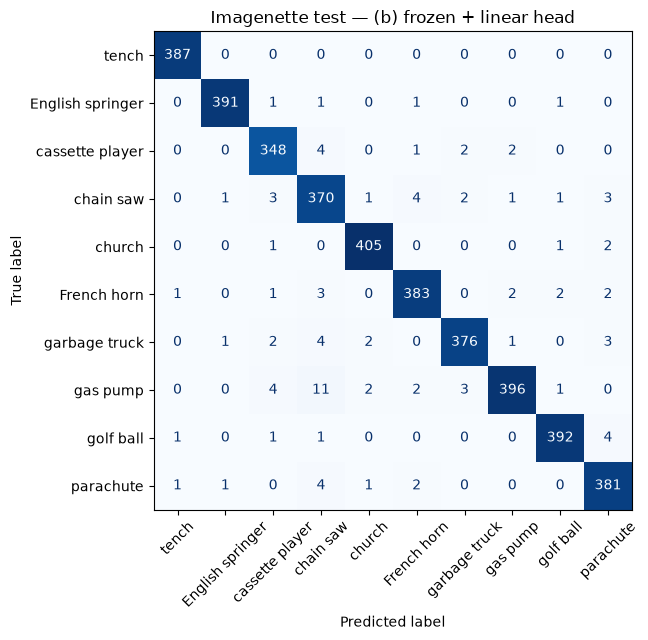

lowest per-class accuracy: {'gas pump': 0.945, 'chain saw': 0.959, 'garbage truck': 0.967}


In [44]:
best_name = results_df["val acc"].astype(float).idxmax()                       # chosen by VALIDATION, not test
print("best model by validation accuracy:", best_name)
best_pred = test_logits_by_model[best_name].argmax(1)
cm_net = confusion_matrix(y_net_test, best_pred)
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ConfusionMatrixDisplay(cm_net, display_labels=class_names).plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title(f"Imagenette test — {best_name}")
plt.tight_layout()
plt.show()
per_class_net = pd.Series(cm_net.diagonal() / cm_net.sum(axis=1), index=class_names).sort_values()
print("lowest per-class accuracy:", per_class_net.head(3).round(3).to_dict())

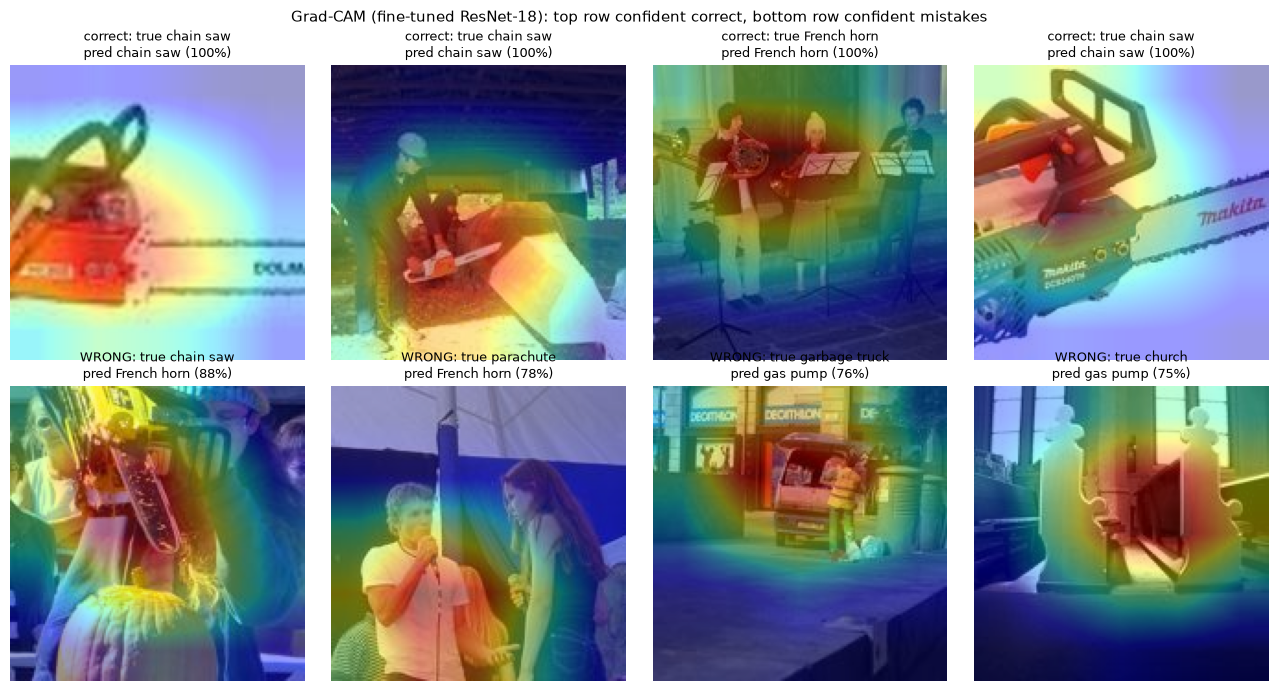

In [45]:
# Grad-CAM on the fine-tuned model: 4 confident correct and 4 wrong test predictions
ft_model.eval()
probs_ft = test_ft["logits"].softmax(1)
pred_ft = probs_ft.argmax(1)
confidence = probs_ft.max(1).values
correct_idx = torch.nonzero(pred_ft == y_net_test).flatten()
wrong_idx = torch.nonzero(pred_ft != y_net_test).flatten()
chosen = torch.cat([correct_idx[confidence[correct_idx].argsort(descending=True)[:4]],
                    wrong_idx[confidence[wrong_idx].argsort(descending=True)[:4]]])
images_for_cam = torch.stack([ft_eval_tf(X_net_test[i]) for i in chosen]).to(DEVICE)
cam_tool = GradCAM(ft_model, ft_model.layer4)
cams_ft, _, cls_ft = cam_tool(images_for_cam)
cam_tool.remove()

fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for ax, i, cam_map, c in zip(axes.ravel(), chosen.tolist(), cams_ft, cls_ft.tolist()):
    ax.imshow(denormalize(ft_eval_tf(X_net_test[i])))
    ax.imshow(cam_map.cpu(), cmap="jet", alpha=0.4)
    verdict = "correct" if c == int(y_net_test[i]) else "WRONG"
    ax.set_title(f"{verdict}: true {class_names[y_net_test[i]]}\npred {class_names[c]} ({confidence[i]:.0%})", fontsize=9)
    ax.axis("off")
plt.suptitle("Grad-CAM (fine-tuned ResNet-18): top row confident correct, bottom row confident mistakes", fontsize=11)
plt.tight_layout()
plt.show()

### Step 8 — Conclusions (computed from the results above)

In [46]:
acc = results_df["test acc"].astype(float)
secs = results_df["train seconds"].astype(float)
scratch_acc, frozen_acc, ft_acc = acc["(a) scratch CNN"], acc["(b) frozen + linear head"], acc["(c) fine-tuned ResNet-18"]
print(f"• Transfer learning beats training from scratch by {(max(frozen_acc, ft_acc) - scratch_acc) * 100:+.1f} points of test accuracy "
      f"with the same data (scratch {scratch_acc:.1%} vs best pretrained {max(frozen_acc, ft_acc):.1%}).")
print(f"• The frozen backbone trains only {int(results_df.loc['(b) frozen + linear head', 'trainable params']):,} parameters "
      f"and took {secs['(b) frozen + linear head']:.0f}s (both resolutions) vs {secs['(c) fine-tuned ResNet-18']:.0f}s for fine-tuning.")
if ft_acc > frozen_acc + 0.005:
    print(f"• Fine-tuning helped: {(ft_acc - frozen_acc) * 100:+.1f} points over the frozen backbone.")
elif frozen_acc > ft_acc + 0.005:
    resolution_note = f", and a lower input resolution (160px vs the probe's {frozen_res}px)" if frozen_res > 160 else ""
    print(f"• Fine-tuning did NOT beat the frozen backbone here ({(ft_acc - frozen_acc) * 100:+.1f} points). "
          f"Likely reasons: ImageNet-like data, a 3-epoch budget{resolution_note}.")
else:
    print(f"• Fine-tuning and the frozen backbone are within 0.5 points ({(ft_acc - frozen_acc) * 100:+.1f}) — the cheaper linear probe is the practical choice.")
for name in ["(b) frozen + linear head", "(c) fine-tuned ResNet-18"]:
    low, high = overlap_df.loc[name, "95% CI low"], overlap_df.loc[name, "95% CI high"]
    verdict = ("higher on images it may have seen in pretraining — its test accuracy is likely optimistic" if low > 0
               else "no detectable difference, but the interval is too wide to rule out a small effect")
    print(f"• {name}: train-named minus val-named accuracy {overlap_df.loc[name, 'gap (train − val named)'] * 100:+.1f} points "
          f"(95% CI {low * 100:+.1f} to {high * 100:+.1f}) → {verdict}.")
print(f"• {1 - from_imagenet_val.float().mean().item():.0%} of the test images follow ImageNet training-set naming, so treat the pretrained "
      f"models' accuracy as an upper bound for truly unseen photos of these classes.")
val_test_gap = (results_df["val acc"].astype(float) - acc).abs().max()
print(f"• Validation and test accuracies agree within {val_test_gap:.1%} for every model, so the validation split was a reliable guide.")

• Transfer learning beats training from scratch by +18.4 points of test accuracy with the same data (scratch 79.2% vs best pretrained 97.6%).
• The frozen backbone trains only 5,130 parameters and took 30s (both resolutions) vs 46s for fine-tuning.
• Fine-tuning did NOT beat the frozen backbone here (-1.4 points). Likely reasons: ImageNet-like data, a 3-epoch budget, and a lower input resolution (160px vs the probe's 224px).
• (b) frozen + linear head: train-named minus val-named accuracy -0.2 points (95% CI -2.8 to +2.3) → no detectable difference, but the interval is too wide to rule out a small effect.
• (c) fine-tuned ResNet-18: train-named minus val-named accuracy -0.1 points (95% CI -3.4 to +3.2) → no detectable difference, but the interval is too wide to rule out a small effect.
• 97% of the test images follow ImageNet training-set naming, so treat the pretrained models' accuracy as an upper bound for truly unseen photos of these classes.
• Validation and test accuracies agree w

**Stretch goals**
1. **A dataset unlike ImageNet**: repeat the comparison on `torchvision.datasets.EuroSAT` (satellite images) or `DTD` (textures). Does fine-tuning overtake the linear probe when the domain differs?
2. **Fine-tune at 224 px** (and for more epochs) — does it close the gap with the frozen model's resolution?
3. **Data efficiency**: train all three on 10%, 25%, 50% of the training split and plot test accuracy vs. training-set size.
4. **Stronger recipes**: add `v2.RandomErasing`, MixUp/CutMix (`v2.MixUp`, `v2.CutMix`), gradual unfreezing, or swap in `efficientnet_b0` / `convnext_tiny`.

### 🗣️ How to talk about this in an interview
- "I compared training from scratch, a frozen pretrained backbone with a linear head, and fine-tuning on Imagenette, with a validation split carved from training for every decision and the official val set used once as the test set."
- "I used each weights' own preprocessing (ImageNet mean/std, sensible resolution), cached frozen features to train the head in seconds, and fine-tuned with a 10× lower backbone learning rate and a one-cycle schedule."
- "Transfer learning won by a wide margin over the from-scratch CNN at equal compute; I report accuracy, trainable parameters, and training time side by side, because the cheapest adequate option usually wins in production."
- "I checked for pretraining overlap — Imagenette is drawn from ImageNet — by splitting the test set by source, and I used Grad-CAM on confident mistakes to see whether errors came from ambiguous images or shortcuts."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Why do CNNs work better than MLPs on images?**

<details><summary>Show answer</summary>

- **30-second answer:** Convolutions use local connectivity and share weights across positions, so they need far fewer parameters and build in the assumption that useful patterns are local and can appear anywhere (translation equivariance). Stacking layers grows the receptive field into a hierarchy of edges → textures → parts → objects.
- **Go deeper:** Pooling and global average pooling add approximate translation invariance; striding and padding break exact equivariance (small shifts can change predictions — "aliasing"). ViTs have weaker built-in assumptions and need more data or augmentation to match CNNs.
- **❌ Common wrong answer:** "CNNs are fully translation invariant" — they are equivariant per layer and only approximately invariant after pooling.

</details>

**Q2. Give the conv output-size and parameter-count formulas, with an example.**

<details><summary>Show answer</summary>

- **30-second answer:** $n_{out} = \lfloor (n + 2p - d(k-1) - 1)/s \rfloor + 1$; parameters $= C_{out} \cdot (C_{in}/g) \cdot k^2 + C_{out}$. Example: 224 input, k=7, s=2, p=3 → 112; `Conv2d(3, 64, 7, bias=False)` has 9,408 parameters.
- **Go deeper:** Parameters don't depend on image size, but compute (FLOPs) scales with output area: ≈ params × H_out × W_out. Depthwise-separable convs cut both by ~k² / (1 + k²/C_out)-ish factors (≈8–9× for 3×3).
- **❌ Common wrong answer:** Forgetting the bias, or the input channels in the kernel volume (counting only `k·k·C_out`).

</details>

**Q3. What is the receptive field and how do you increase it?**

<details><summary>Show answer</summary>

- **30-second answer:** The input region that can affect a unit. Recurrence: $r \leftarrow r + (k-1)d\,j$, $j \leftarrow j s$. Increase it with depth, stride/pooling, larger or dilated kernels, or attention.
- **Go deeper:** Theoretical receptive field (435 px for ResNet-18) overstates what matters: the effective receptive field is roughly Gaussian and much smaller. Detection/segmentation need large context, hence FPNs, dilation, and attention.
- **❌ Common wrong answer:** "Receptive field equals the kernel size."

</details>

**Q4. Why do residual connections help?**

<details><summary>Show answer</summary>

- **30-second answer:** Each block computes $x + F(x)$, so gradients flow through the identity path and a block can easily learn identity. This solved the degradation problem: deeper plain nets (even with BatchNorm) had *higher training error* than shallower ones.
- **Go deeper:** When shapes change, the shortcut is a 1×1 conv with stride + BN. Pre-activation ResNets put BN-ReLU before convs for even cleaner identity paths. Residuals are everywhere now: Transformers, U-Nets, diffusion models.
- **❌ Common wrong answer:** "They fix overfitting" — they fix optimization, not generalization.

</details>

**Q5. How does BatchNorm behave in training vs inference, and when is it a problem?**

<details><summary>Show answer</summary>

- **30-second answer:** In training it normalizes with the batch's per-channel mean/variance (over N, H, W) and updates running averages; in eval it uses the running averages, so outputs don't depend on the batch. Problems: forgetting `model.eval()`, tiny batch sizes (noisy statistics), and a train/serve distribution shift in the running stats.
- **Go deeper:** For small batches use GroupNorm/LayerNorm or freeze BN (keep it in eval mode) while fine-tuning. Convs followed by BN don't need a bias. BN can be fused into the preceding conv for faster inference.
- **❌ Common wrong answer:** "`model.eval()` turns off gradients" — that's `torch.no_grad()` / `inference_mode()`.

</details>

**Q6. When do you freeze a pretrained backbone and when do you fine-tune it?**

<details><summary>Show answer</summary>

- **30-second answer:** Small dataset or data similar to the pretraining data → freeze and train a head (fast, hard to overfit). Larger or different-looking data → fine-tune everything with a lower backbone learning rate (≈10× lower), warmup, and early stopping on validation.
- **Go deeper:** Middle grounds: unfreeze only later stages, gradual unfreezing, discriminative learning rates, parameter-efficient methods (adapters/LoRA for ViTs). Always use the weights' preprocessing; keep frozen BN in eval mode.
- **❌ Common wrong answer:** "Always fine-tune everything with the default learning rate" — a high LR destroys pretrained features (catastrophic forgetting).

</details>

**Q7. What does a 1×1 convolution do?**

<details><summary>Show answer</summary>

- **30-second answer:** It mixes channels at each pixel independently — a per-pixel linear layer across channels. Used to reduce/expand channels cheaply (bottlenecks in ResNet-50, Inception), as the pointwise half of depthwise-separable convs, and to match shapes in skip connections.
- **Go deeper:** A 1×1 conv from 256→64 before a 3×3 conv cuts that 3×3 conv's cost ~4×. With stride 2 it downsamples in shortcut paths.
- **❌ Common wrong answer:** "It does nothing because the kernel is one pixel."

</details>

**Q8. CNN or Vision Transformer for a new project?**

<details><summary>Show answer</summary>

- **30-second answer:** With limited data or compute, or edge deployment, start with a pretrained CNN (ResNet/EfficientNet/ConvNeXt). With large data, or when you can use a strong pretrained ViT (e.g. CLIP/DINOv2 backbones), ViTs often transfer better and scale well. Benchmark both on your validation set.
- **Go deeper:** ViTs lack locality bias, so from-scratch training needs more data/augmentation (DeiT recipes); ConvNeXt showed a modernized CNN matches Swin Transformers at similar compute. Hybrid designs are common in detection.
- **❌ Common wrong answer:** "Transformers are always better now."

</details>

### 💻 Coding

**Q9. Implement a 2-D convolution efficiently without `F.conv2d`.**

<details><summary>Show answer</summary>

- **30-second answer:** im2col: `cols = F.unfold(x, k, padding=p, stride=s)` → `(N, C·k·k, L)`; `out = W.view(C_out, -1) @ cols + b[:, None]`; reshape to `(N, C_out, H_out, W_out)` using the size formula.
- **Go deeper:** Memory cost is the unfolded matrix (C·k²·L per image); production libraries use Winograd/FFT or direct kernels (cuDNN/MPS). In NumPy you can build the patches with `sliding_window_view` + `einsum`.
- **❌ Common wrong answer:** Four nested Python loops — correct but orders of magnitude too slow, and it misses the "convolution is a matrix multiply" insight.

</details>

**Q10. Walk through Grad-CAM in code.**

<details><summary>Show answer</summary>

- **30-second answer:** Hook the last conv stage to save activations A and their gradients; backprop the class **logit**; weights α = gradients averaged over H, W; CAM = ReLU(Σ α_k A_k); upsample and normalize.
- **Go deeper:** Use logits not softmax probabilities (softmax couples classes). Run in eval mode. Validate with sanity checks (randomizing weights must change the map). Variants: Grad-CAM++, Score-CAM; for ViTs use attention rollout or gradient-based token attributions.
- **❌ Common wrong answer:** Taking gradients with respect to the input image — that's a vanilla saliency map, a different (noisier) method.

</details>

**Q11. Write a function for top-k accuracy and a per-class accuracy report.**

<details><summary>Show answer</summary>

- **30-second answer:** `(logits.topk(k, 1).indices == y[:, None]).any(1).float().mean()`; per-class accuracy = `diag(cm) / cm.sum(axis=1)` from the confusion matrix.
- **Go deeper:** Report macro averages for imbalanced data; top-5 for fine-grained classes; include confidence calibration (ECE) when probabilities are used downstream.
- **❌ Common wrong answer:** Dividing the confusion matrix diagonal by column sums (that's precision), or using `argmax` for top-k.

</details>

### 🐛 Debugging Scenarios

**Q12. Validation accuracy was 90% during training, but the deployed model is much worse on the same kind of images. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Preprocessing parity (RGB/BGR, resize and crop, 0–1 scaling, mean/std, interpolation), `model.eval()` in the service, and whether the right checkpoint/weights file was loaded. Then data drift (camera, lighting, compression).
- **Go deeper:** Save a few production inputs, run them through the training pipeline and the service, and diff the tensors and logits. Log per-channel input means in production. Keep preprocessing in one shared, tested module.
- **❌ Common wrong answer:** "The model is overfitting — add dropout" without checking the pipeline.

</details>

**Q13. Fine-tuning a pretrained model gives worse results than just training a linear head. Why might that be?**

<details><summary>Show answer</summary>

- **30-second answer:** Learning rate too high for the backbone (destroying features), no warmup, too few epochs to recover, tiny batches corrupting BatchNorm statistics, too little data (overfitting), or a lower input resolution than the probe used. With data close to the pretraining domain, a linear probe is genuinely hard to beat.
- **Go deeper:** Use discriminative LRs, warmup + cosine/one-cycle schedule, freeze BN or use larger batches, stronger augmentation, and compare both options on the same validation split, as the mini project does.
- **❌ Common wrong answer:** "Fine-tuning is always better than freezing."

</details>

**Q14. Your GPU benchmark says ResNet-50 runs in 0.3 ms per batch of 64. What's wrong?**

<details><summary>Show answer</summary>

- **30-second answer:** GPU kernels run asynchronously; the timer stopped before the work finished. Synchronize (`torch.cuda.synchronize()` / `torch.mps.synchronize()`) before reading the clock, warm up first, and average many runs.
- **Go deeper:** Also exclude first-call compilation/caching, fix input shapes, and measure end-to-end including data loading and preprocessing. Report p50/p95 latency and throughput separately.
- **❌ Common wrong answer:** "The GPU is just that fast."

</details>

### 🏗️ Design

**Q15. Design an image classification service for a retail app with a 50 ms p95 latency budget on CPU servers.**

<details><summary>Show answer</summary>

- **30-second answer:** Start from a pretrained efficient backbone (MobileNetV3/EfficientNet-B0/ResNet-18), fine-tune on labeled product images with a proper validation split, export (`torch.export` → AOTInductor or ONNX Runtime), quantize to int8 if accuracy holds, fix the input size, and benchmark p95 on the target CPU *including* decoding and resizing. Add dynamic batching only if it keeps p95 under budget.
- **Go deeper:** Monitor input drift and confidence; route low-confidence images to a bigger model or human review; version the preprocessing with the model; A/B test; keep a golden test set for regression checks.
- **❌ Common wrong answer:** "Use the biggest ViT for accuracy" without measuring latency, or benchmarking on a GPU laptop instead of the production CPU.

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** Output shape of `nn.Conv2d(3, 16, kernel_size=5, stride=2, padding=2)` applied to a tensor of shape `(8, 3, 64, 64)`?
<details><summary>Answer</summary>

`(8, 16, 32, 32)` — (64 + 4 − 4 − 1) // 2 + 1 = 32.
</details>

**2.** How many parameters does `nn.Conv2d(16, 32, 3)` have?
<details><summary>Answer</summary>

`4,640` — 32 × 16 × 3 × 3 = 4,608 weights + 32 biases.
</details>

**3.** `torch.topk(torch.tensor([0.1, 0.5, 0.2, 0.9]), 2).indices`
<details><summary>Answer</summary>

`tensor([3, 1])` — indices of the two largest values, largest first.
</details>

**4.** You call `model.eval()` on a ResNet-18. Are gradients still computed if you call `loss.backward()`?
<details><summary>Answer</summary>

**Yes.** `eval()` only switches BatchNorm (and Dropout, which ResNet-18 doesn't have) to inference behaviour. To skip gradient tracking use `torch.no_grad()` or `torch.inference_mode()`.
</details>

**5.** Two stacked 3×3 convolutions with stride 1: what is the receptive field, and how many weights do they have for C channels in and out (no bias), compared with a single 5×5 conv?
<details><summary>Answer</summary>

Receptive field **5×5**; weights **2 × 9C² = 18C²** vs **25C²** for one 5×5 — fewer parameters plus an extra nonlinearity (VGG's key idea).
</details>

## 📚 Resources

### 📖 Official Docs
- [Transforming images, videos, boxes and more](https://docs.pytorch.org/vision/stable/transforms.html) — the transforms v2 guide, including boxes and masks
- [Models and pre-trained weights](https://docs.pytorch.org/vision/stable/models.html) — every weights enum with its accuracy and preprocessing
- [Transfer Learning for Computer Vision Tutorial](https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html) — official fine-tuning vs feature-extraction walkthrough
- [torch.export](https://docs.pytorch.org/docs/2.14/user_guide/torch_compiler/export.html) — exporting models to a portable graph, with dynamic shapes

### 🎥 Videos
- [3Blue1Brown — But what is a convolution?](https://www.youtube.com/watch?v=KuXjwB4LzSA) (~23 min) — beautiful visual intuition for convolution, from image blurs to probability
- [Stanford CS231n — Lecture 5 | Convolutional Neural Networks](https://www.youtube.com/watch?v=bNb2fEVKeEo) (~1 h 08 min) — the classic university lecture on conv layers, pooling, and the history behind them
- [Yannic Kilcher — Deep Residual Learning for Image Recognition (Paper Explained)](https://www.youtube.com/watch?v=GWt6Fu05voI) (~31 min) — a careful read-through of the ResNet paper and the degradation problem

### 📄 Papers
- [ImageNet Classification with Deep Convolutional Neural Networks](https://papers.nips.cc/paper_files/paper/2012/hash/c399862d3b9d6b76c8436e924a68c45b-Abstract.html) — Krizhevsky, Sutskever, Hinton (2012), AlexNet
- [Very Deep Convolutional Networks for Large-Scale Image Recognition](https://arxiv.org/abs/1409.1556) — Simonyan & Zisserman (2014), VGG
- [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385) — He et al. (2015), ResNet
- [Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift](https://arxiv.org/abs/1502.03167) — Ioffe & Szegedy (2015)
- [EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks](https://arxiv.org/abs/1905.11946) — Tan & Le (2019)
- [An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale](https://arxiv.org/abs/2010.11929) — Dosovitskiy et al. (2020), ViT
- [A ConvNet for the 2020s](https://arxiv.org/abs/2201.03545) — Liu et al. (2022), ConvNeXt
- [How transferable are features in deep neural networks?](https://arxiv.org/abs/1411.1792) — Yosinski et al. (2014), the classic transfer-learning study
- [Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization](https://arxiv.org/abs/1610.02391) — Selvaraju et al. (2017)
- [Sanity Checks for Saliency Maps](https://arxiv.org/abs/1810.03292) — Adebayo et al. (2018), the model randomization test we ran

### 📘 Books & Courses
- [CS231n Deep Learning for Computer Vision — Convolutional Networks notes](https://cs231n.github.io/convolutional-networks/) — the best written explanation of conv arithmetic
- [Dive into Deep Learning — 7. Convolutional Neural Networks](https://d2l.ai/chapter_convolutional-neural-networks/index.html) — free interactive book chapter with PyTorch code
- [Practical Deep Learning for Coders](https://course.fast.ai/) — fast.ai's free, top-down course built around transfer learning

### 🏋️ Practice
- [fastai/imagenette](https://github.com/fastai/imagenette) — the dataset used here, with public leaderboards to benchmark your recipes
- [Kaggle Learn — Computer Vision](https://www.kaggle.com/learn/computer-vision) — short exercises on convolution, pooling, and transfer learning

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Convolution | local, weight-shared pattern detector | `nn.Conv2d(C_in, C_out, k, stride, padding, dilation, groups)` |
| Output size | spatial size after conv/pool | $\lfloor (n + 2p - d(k-1) - 1)/s \rfloor + 1$ |
| Parameters | learnable weights | $C_{out} \cdot C_{in}/g \cdot k^2 + C_{out}$ |
| Receptive field | input region seen | $r \mathrel{+}= (k-1)\,d\,j$, $j \mathrel{*}= s$ |
| Pooling | downsample / summarize | `MaxPool2d`, `AdaptiveAvgPool2d(1)` |
| BatchNorm | per-channel standardization | batch stats in `train()`, running stats in `eval()` |
| Skip connection | trainable depth | `y = F.relu(x + F(x))`, 1×1 conv shortcut when shapes change |
| Augmentation | label-preserving randomness, train only | `v2.RandomResizedCrop`, `v2.RandomHorizontalFlip`, `tv_tensors` for boxes |
| Normalization | match training statistics | compute mean/std on train; `weights.transforms()` for pretrained |
| Transfer learning | reuse pretrained features | freeze + head, or fine-tune with lower backbone LR (param groups) |
| Evaluation | beyond accuracy | `confusion_matrix`, per-class recall, `logits.topk(k)` |
| Grad-CAM | where evidence came from | hooks on last conv; α = mean grad; ReLU(Σ α·A) |
| Export | portable graph | `torch.export.export(model, args, dynamic_shapes=...)`, `torch.export.save/load` |
| Benchmark | honest latency | warmup, `synchronize`, p50/p95 at batch 1, throughput at batch N |

## ➡️ What's Next

**[03 · YOLO Object Detection](03_YOLO_Object_Detection.ipynb)** — classification answers *what* is in an image; detection answers *what and where*, reusing everything here (a CNN backbone, augmentation that moves boxes, IoU and NMS from the OpenCV notebook) to find every object with a bounding box.